In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
loan_df = pd.read_csv(r"C:\Users\Itanas\Desktop\ML/Loan_Default.csv")
 
loan_df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [2]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

In [3]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.500000,42917.476598,24890.000000,62057.25000,99224.50000,136391.750000,1.735590e+05
year,148670.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


In [4]:
loan_df["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

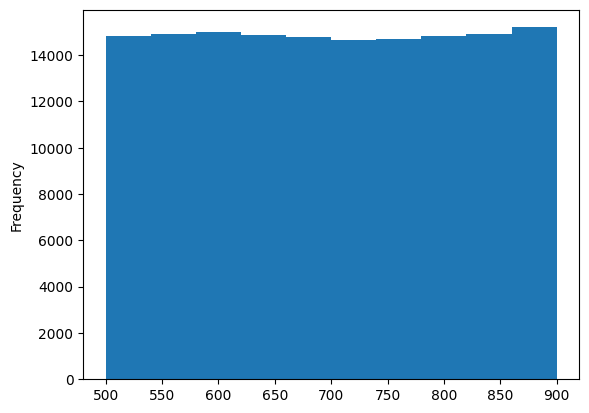

In [5]:
loan_df["Credit_Score"].plot.hist()

In [6]:
# numeric cutoff
loan_df["Fake_Target"] = np.where(loan_df["Credit_Score"] < 580, 1, 0)
 
loan_df["Fake_Target"].value_counts()

Fake_Target
0    118933
1     29737
Name: count, dtype: int64

In [7]:
loan_df["loan_type"].value_counts()

loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

<Axes: xlabel='Status'>

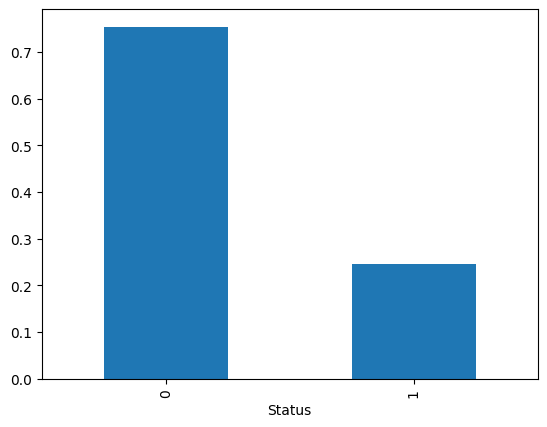

In [8]:
loan_df["Status"].value_counts(normalize=True).plot.bar()

In [9]:
loan_df = loan_df.drop("Fake_Target", axis=1)

<Axes: ylabel='Frequency'>

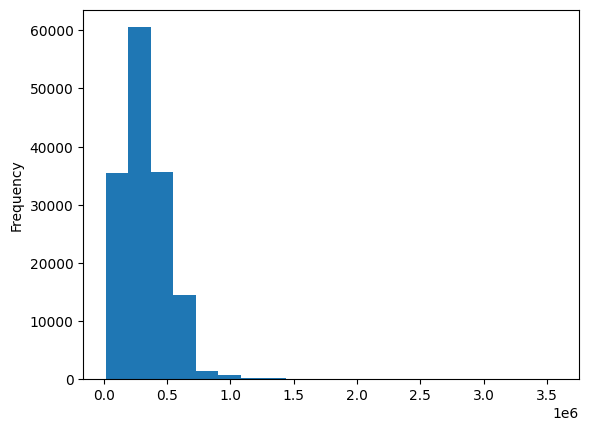

In [10]:
loan_df["loan_amount"].plot.hist(bins=20)

<Axes: ylabel='loan_amount'>

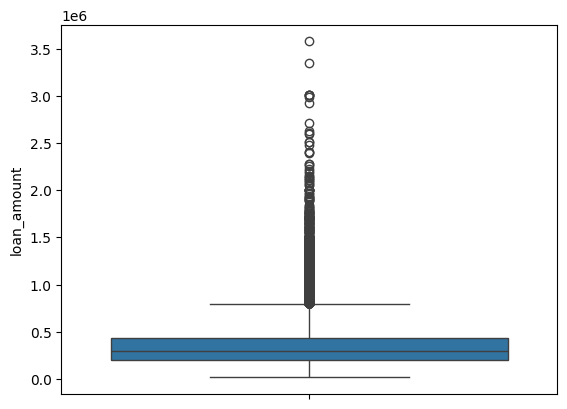

In [11]:
sns.boxplot(loan_df["loan_amount"])

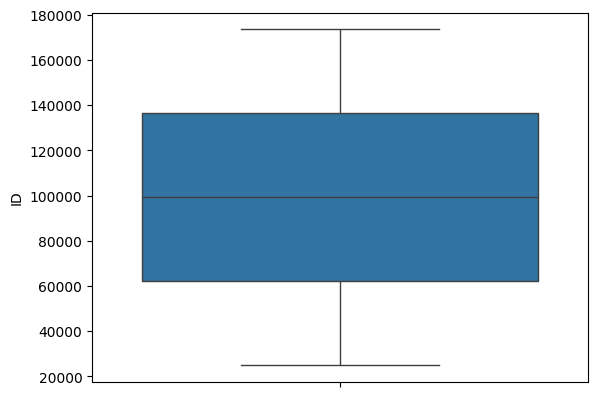

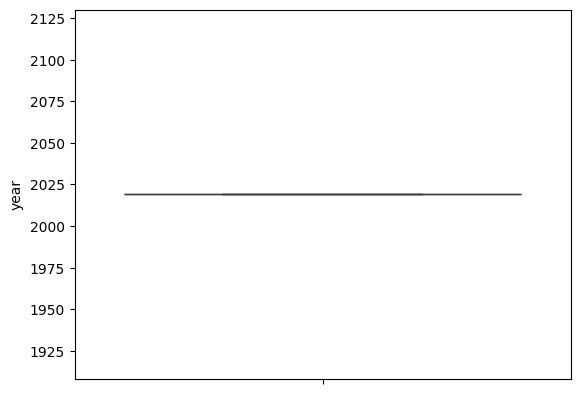

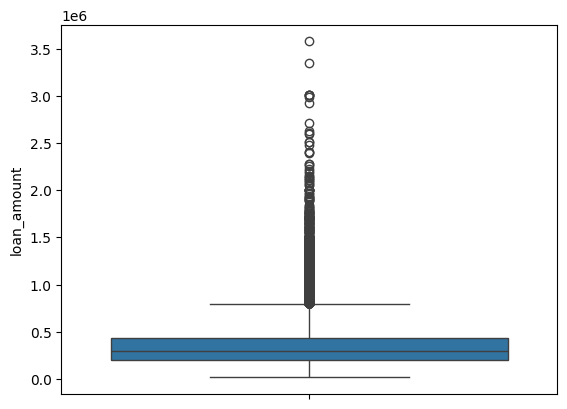

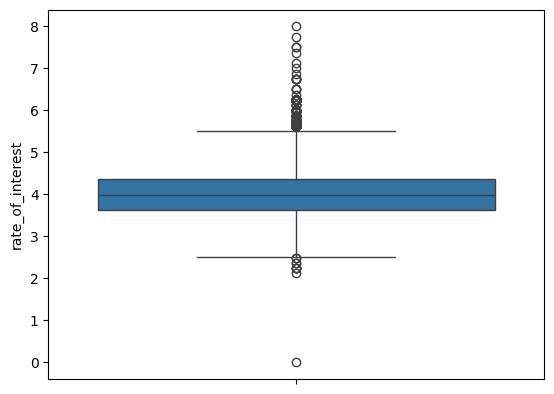

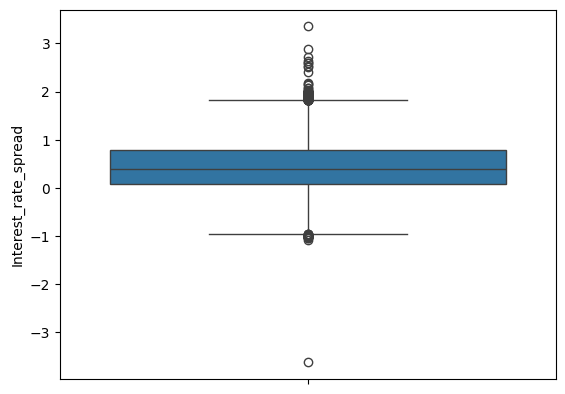

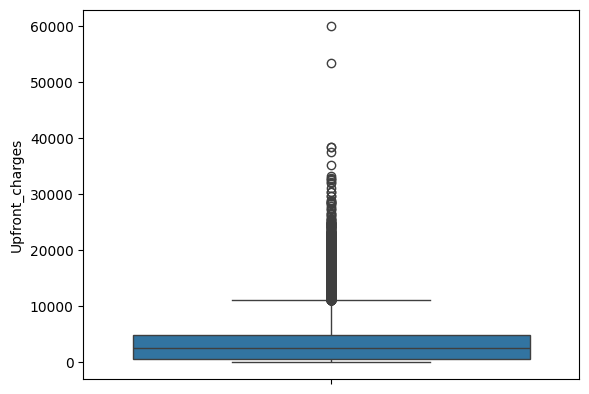

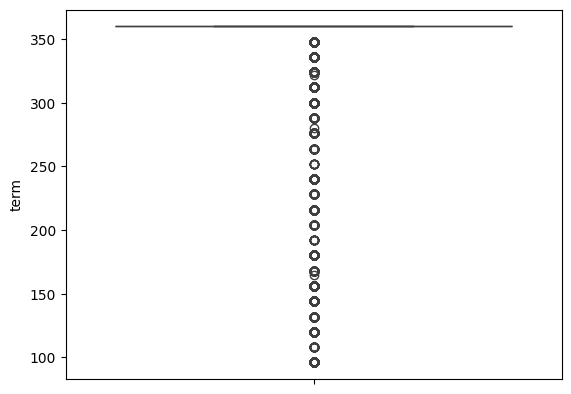

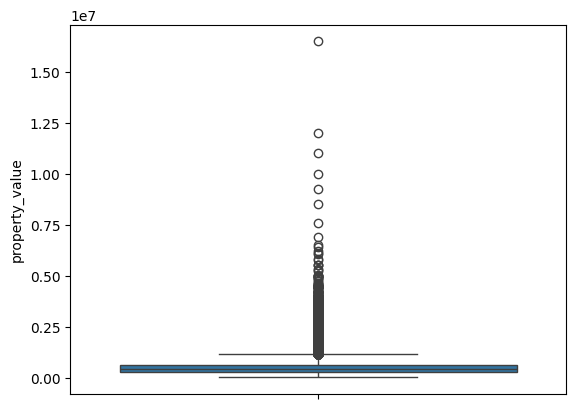

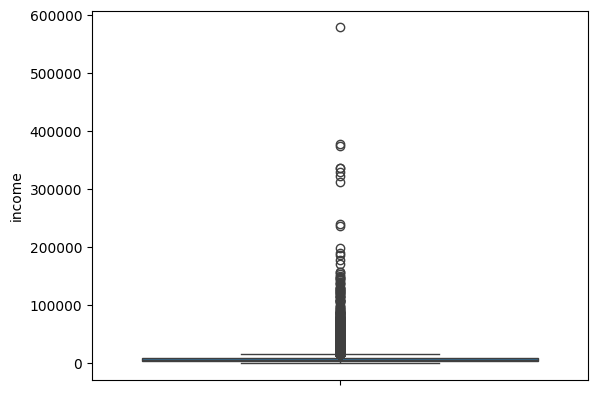

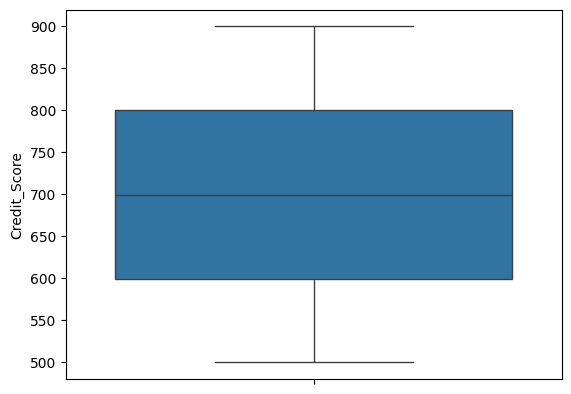

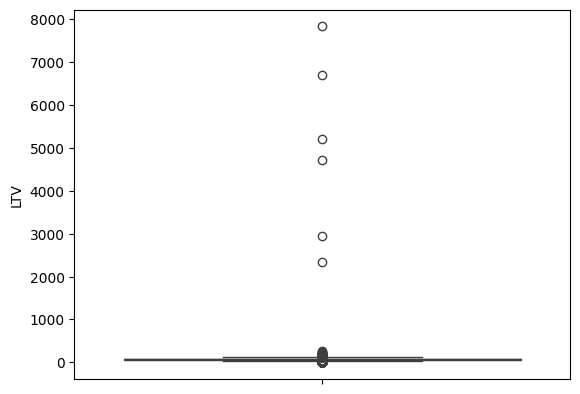

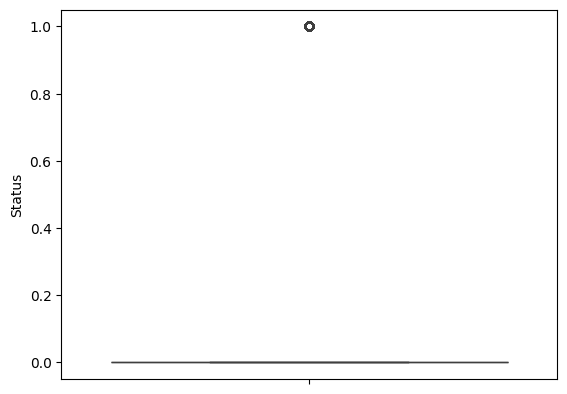

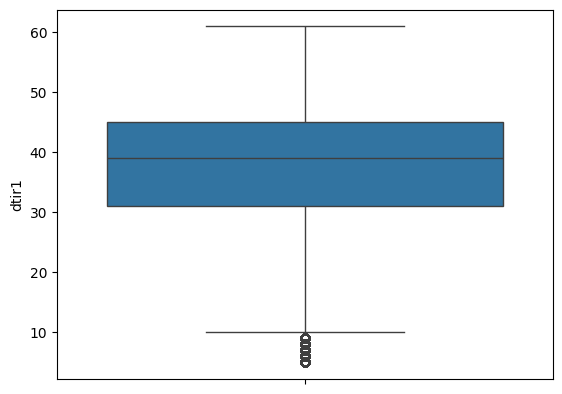

In [12]:
# select numeric dtype columns and plot vs target
 
for column in loan_df.select_dtypes("number").columns:
    sns.boxplot(loan_df[column]).set(ylabel=column)
    plt.show()

<Axes: ylabel='loan_amount'>

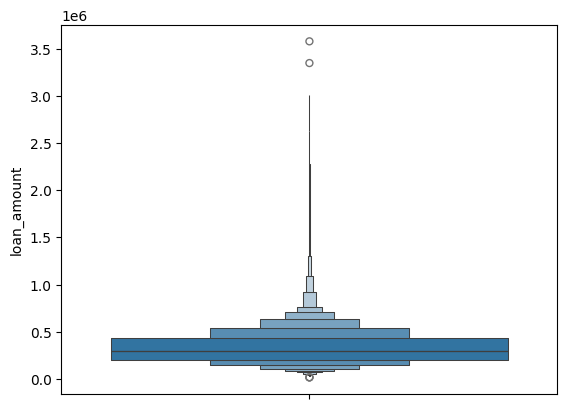

In [13]:
sns.boxenplot(loan_df["loan_amount"])

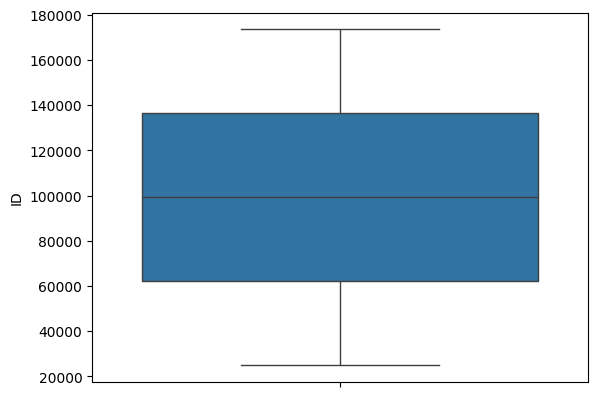

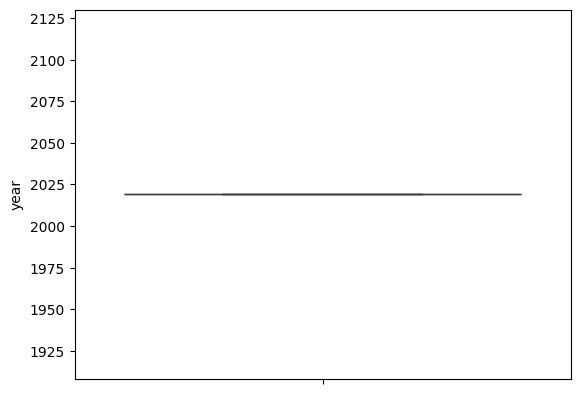

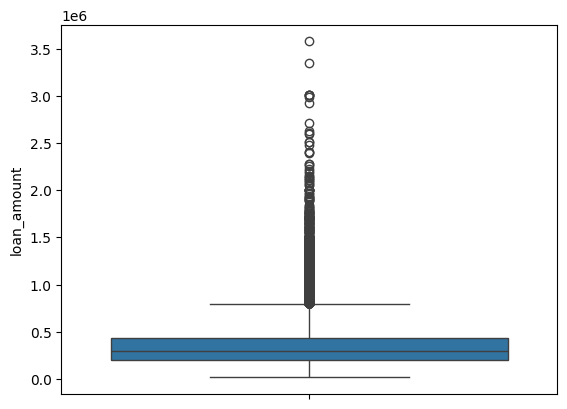

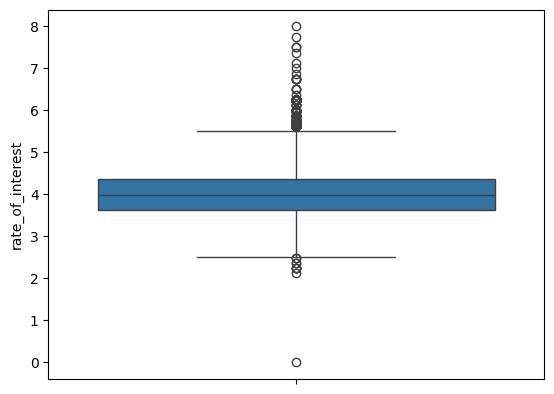

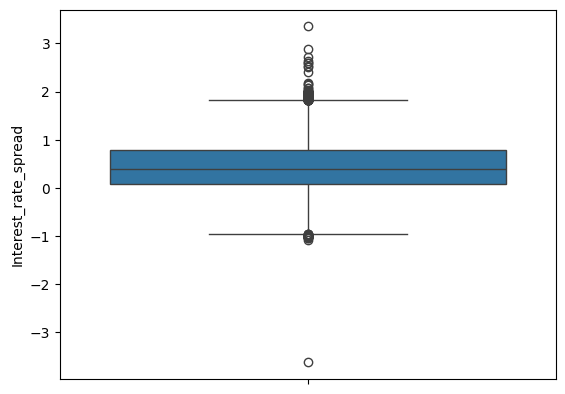

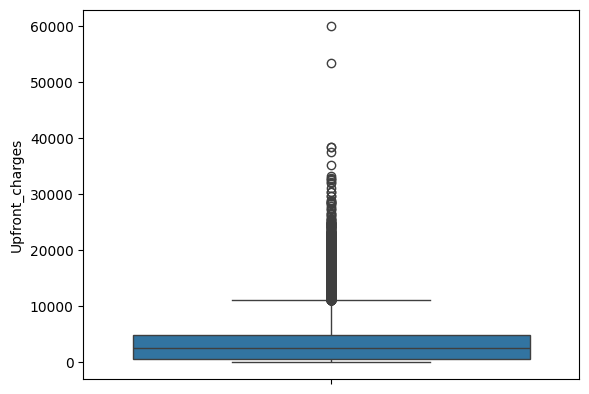

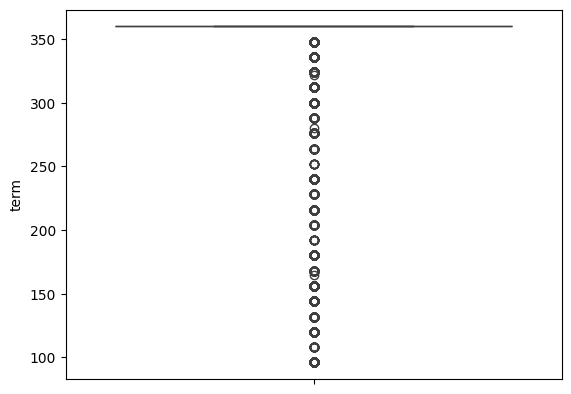

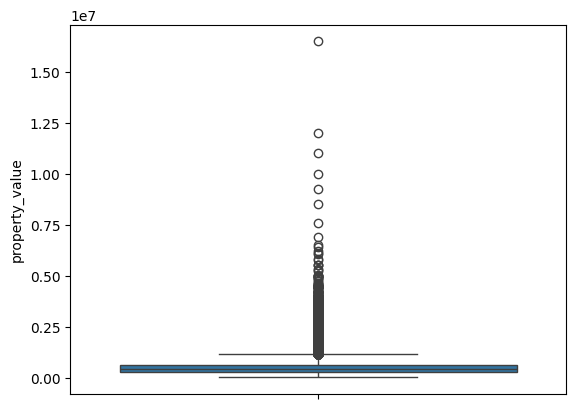

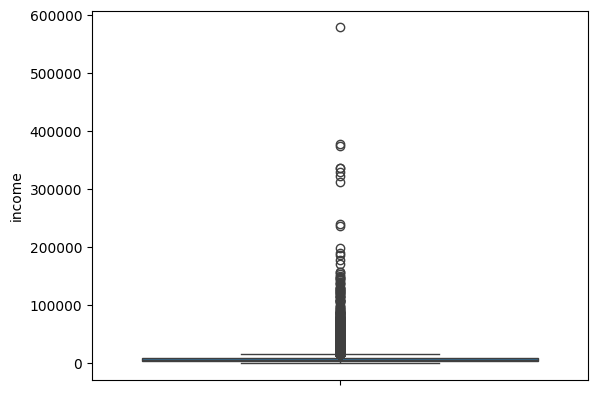

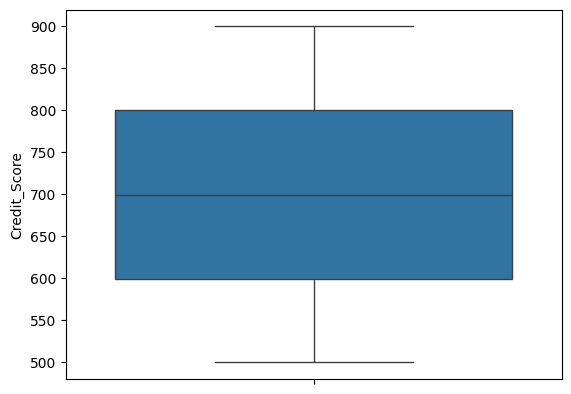

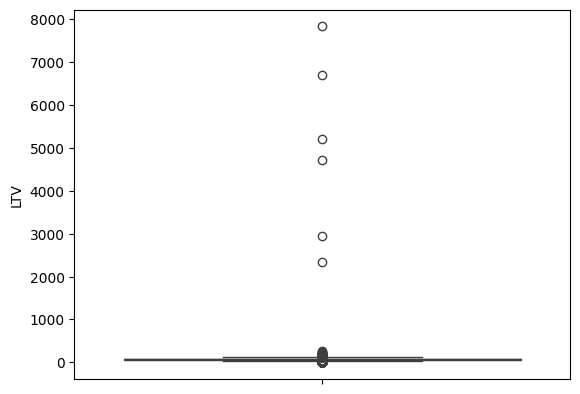

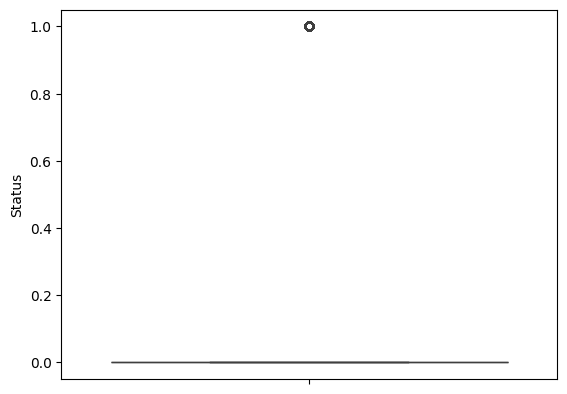

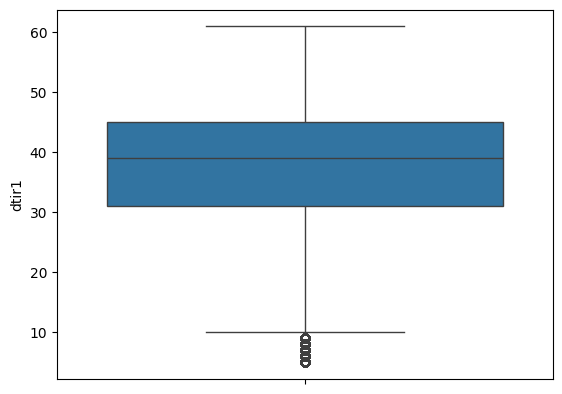

In [14]:
# select numeric dtype columns and plot vs target

 

for column in loan_df.select_dtypes("number").columns:

    sns.boxplot(loan_df[column]).set(ylabel=column)

    plt.show()

<Axes: ylabel='Gender'>

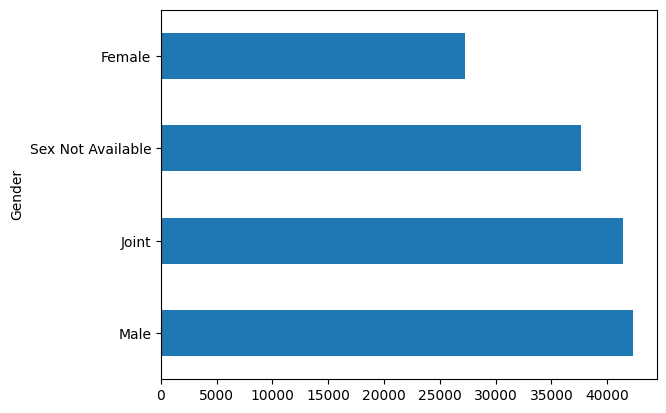

In [15]:
loan_df["Gender"].value_counts().plot.barh()

C:\Users\Itanas\AppData\Local\Temp\ipykernel_36888\577360841.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in loan_df.select_dtypes("object").columns:


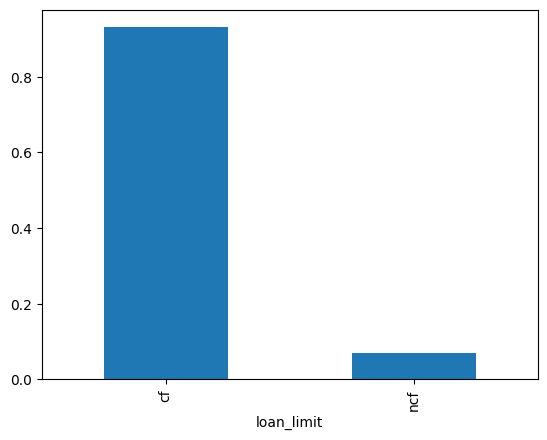

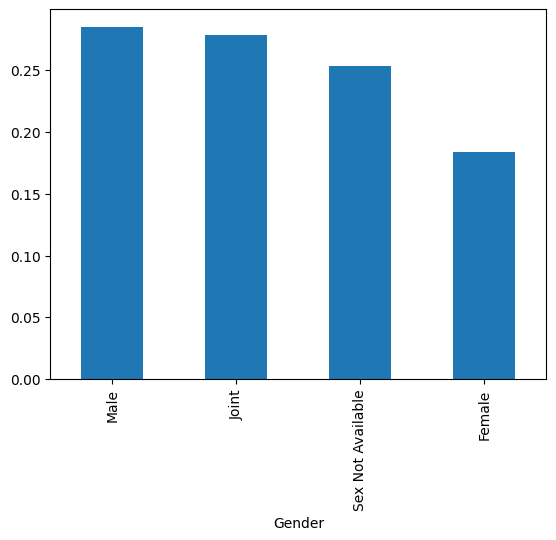

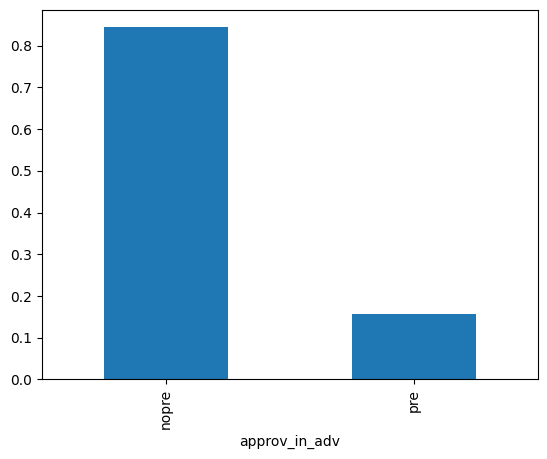

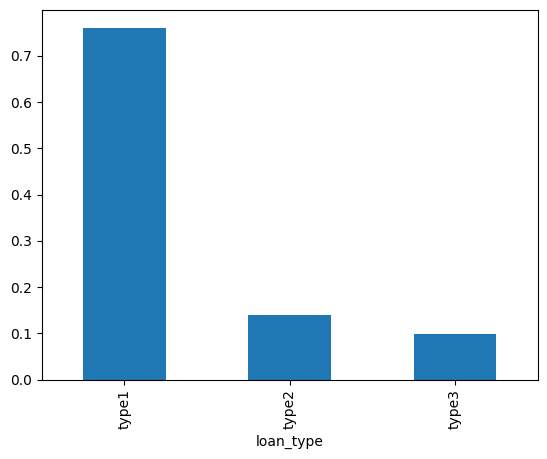

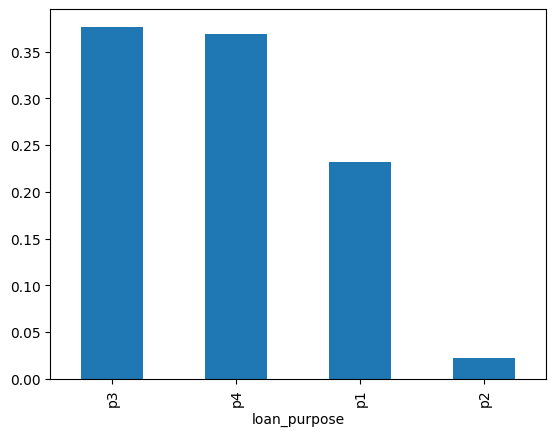

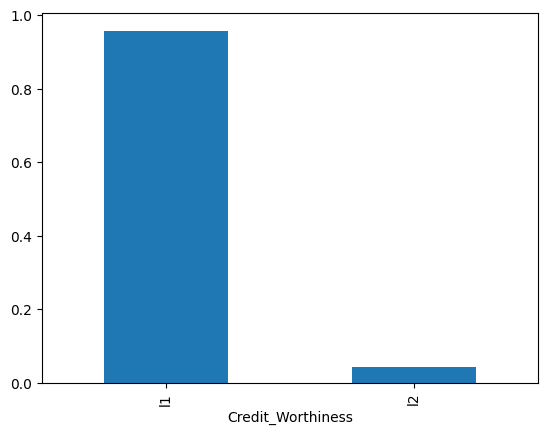

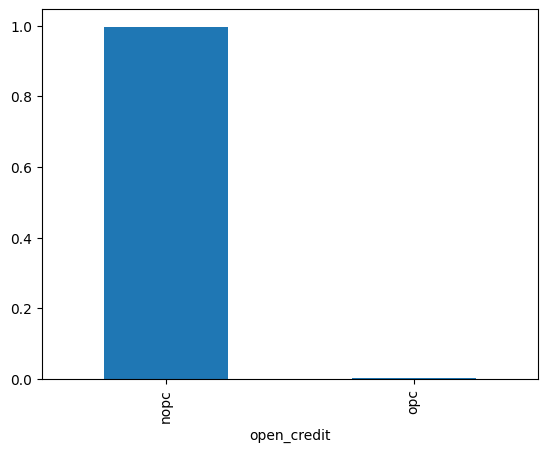

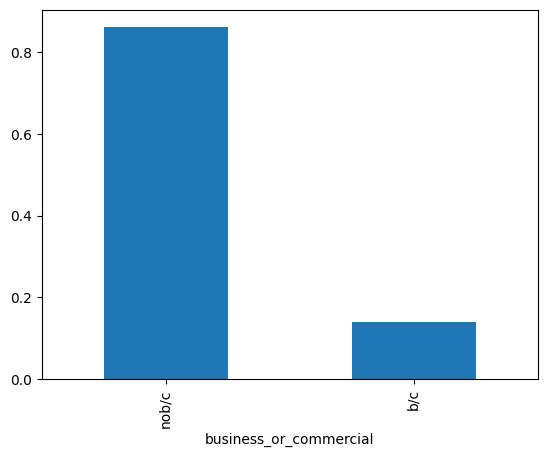

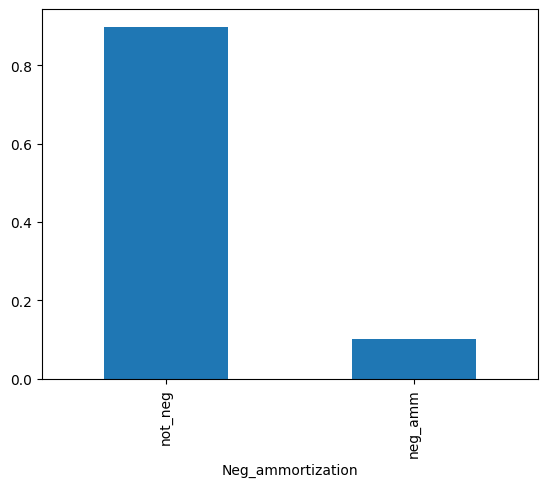

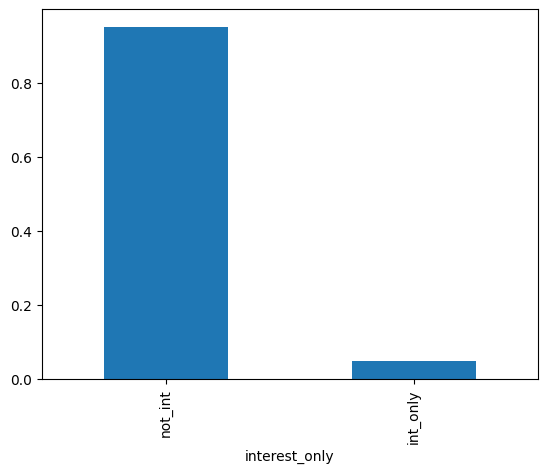

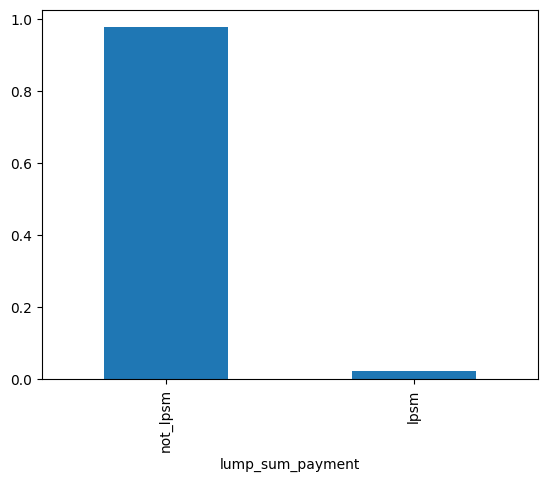

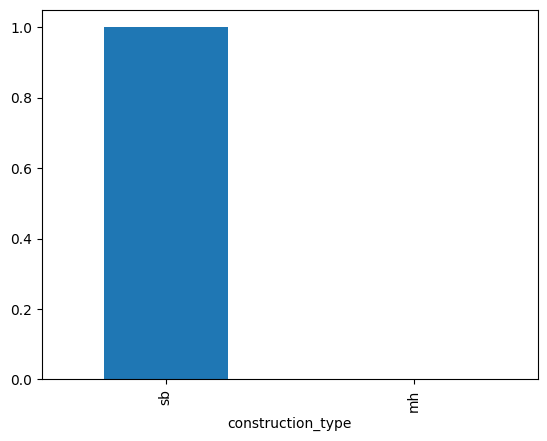

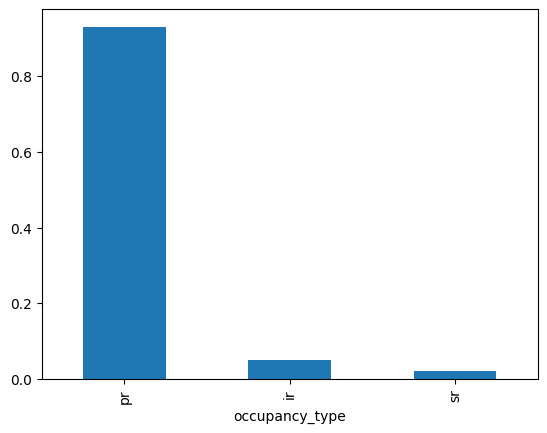

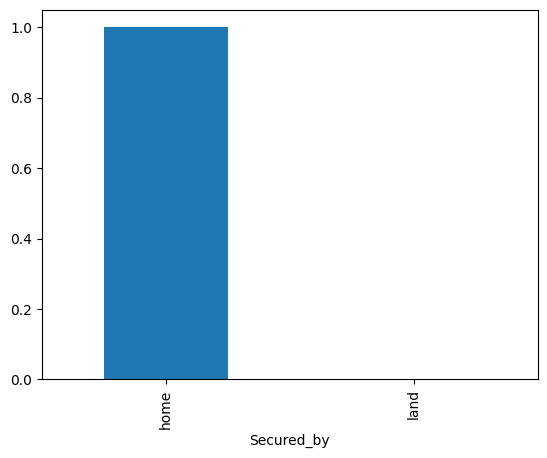

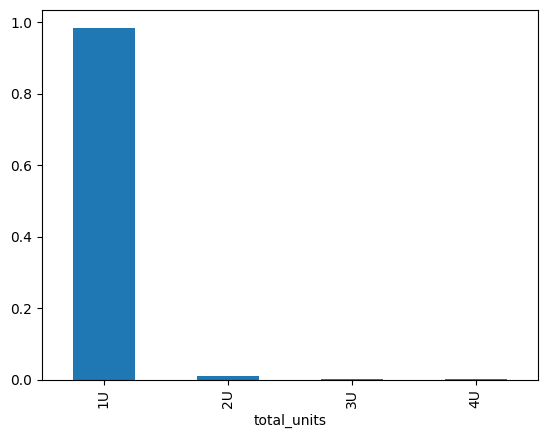

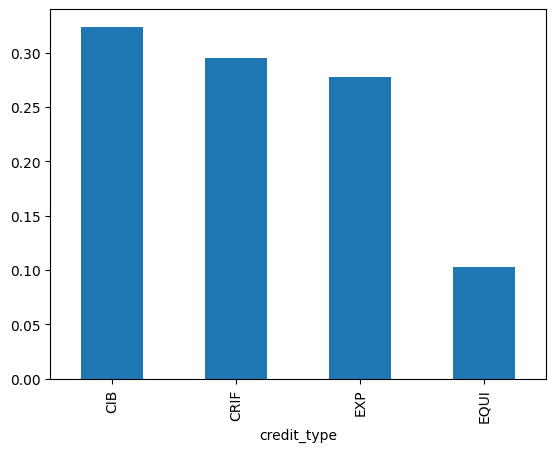

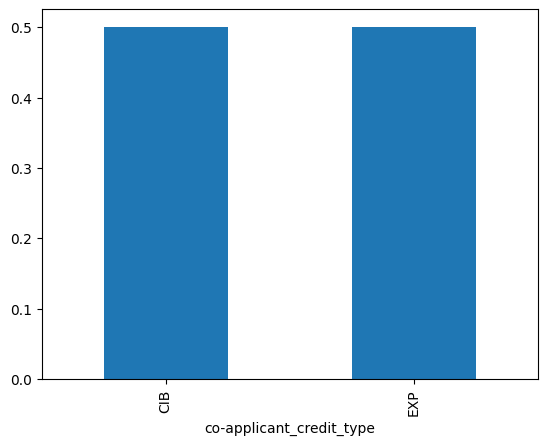

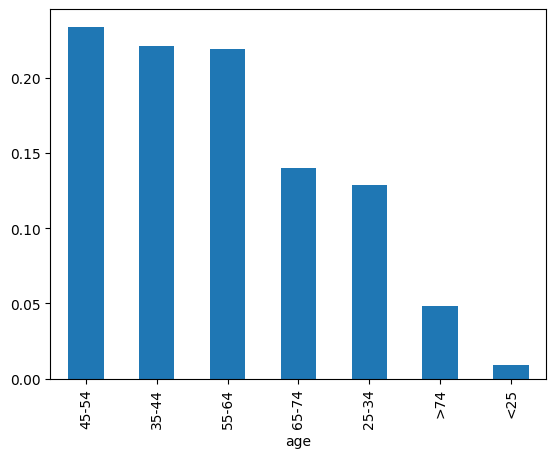

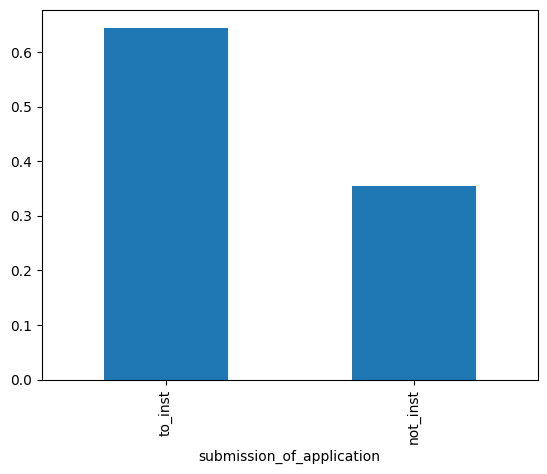

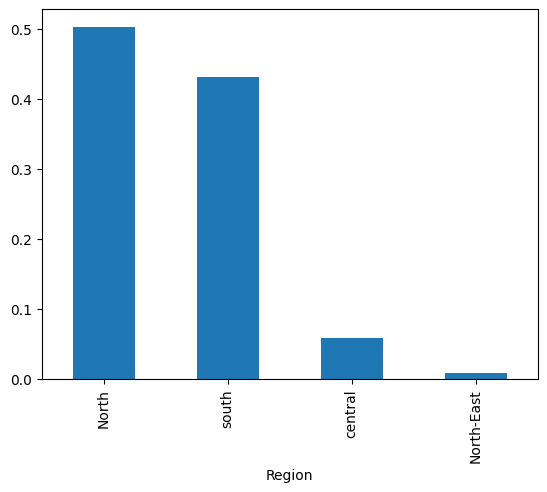

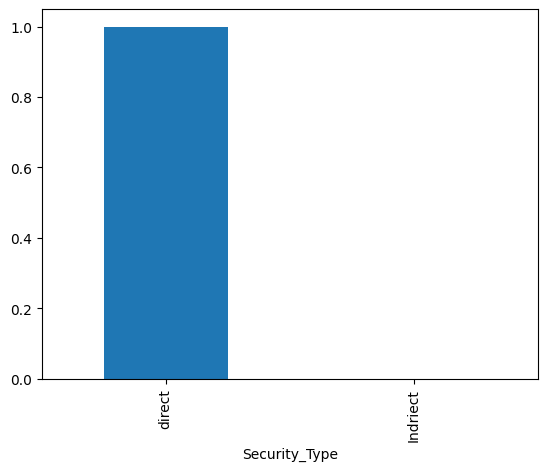

In [16]:
# select object dtype columns and plot vs target

 

for column in loan_df.select_dtypes("object").columns:

    loan_df[column].value_counts(normalize=True).plot.bar()

    plt.show()



<Axes: xlabel='loan_amount', ylabel='property_value'>

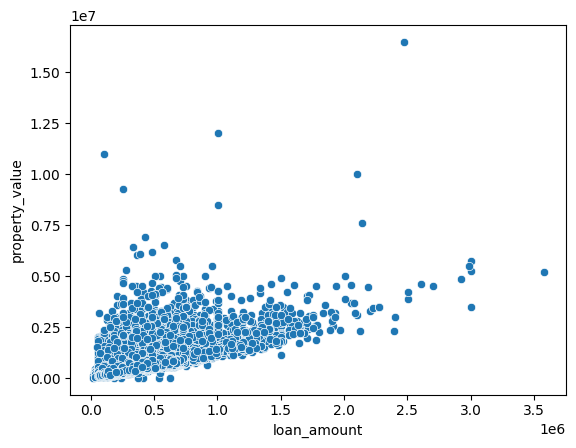

In [17]:
sns.scatterplot(loan_df, x="loan_amount", y="property_value")

In [18]:
loan_df["loan_amount"].corr(loan_df["property_value"])

np.float64(0.7342490169595312)

In [19]:
loan_df["loan_amount"].corr(loan_df["Status"])

np.float64(-0.036825275544374515)

In [20]:
loan_df.corr(numeric_only=True).round(2)

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
ID,1.00,NaN,-0.00,0.00,0.00,-0.01,-0.00,0.00,0.00,-0.00,-0.01,0.00,-0.01
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,-0.00,NaN,1.00,-0.15,-0.38,0.07,0.17,0.73,0.46,0.00,0.04,-0.04,0.02
rate_of_interest,0.00,NaN,-0.15,1.00,0.61,-0.08,0.21,-0.12,-0.04,-0.00,-0.00,0.02,0.06
Interest_rate_spread,0.00,NaN,-0.38,0.61,1.00,0.03,-0.16,-0.33,-0.15,-0.00,0.04,NaN,0.08
Upfront_charges,-0.01,NaN,0.07,-0.08,0.03,1.00,-0.05,0.05,0.02,-0.00,-0.03,-0.02,0.00
term,-0.00,NaN,0.17,0.21,-0.16,-0.05,1.00,0.05,-0.05,-0.00,0.11,-0.00,0.11
property_value,0.00,NaN,0.73,-0.12,-0.33,0.05,0.05,1.00,0.41,0.00,-0.22,-0.05,-0.06
income,0.00,NaN,0.46,-0.04,-0.15,0.02,-0.05,0.41,1.00,0.00,-0.07,-0.07,-0.27
Credit_Score,-0.00,NaN,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,1.00,-0.01,0.00,-0.00


<Axes: >

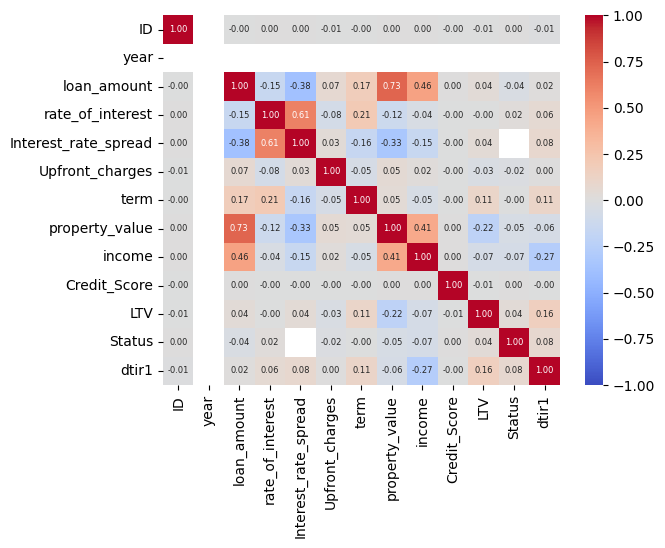

In [23]:
sns.heatmap(
    loan_df.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size":6}
)

<Axes: xlabel='Status', ylabel='loan_amount'>

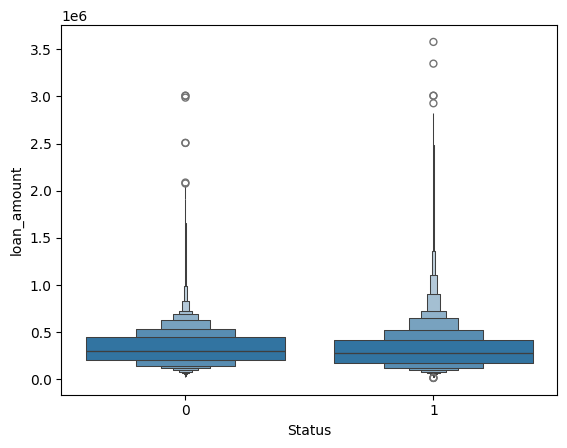

In [24]:
sns.boxenplot(loan_df, x="Status", y="loan_amount")

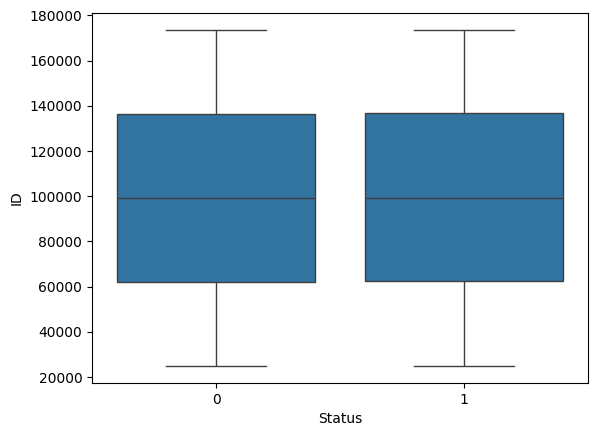

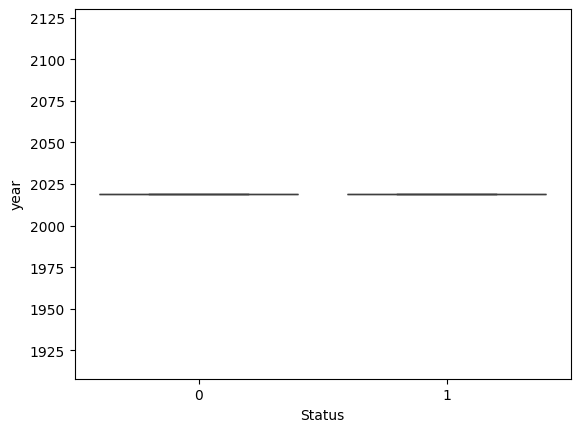

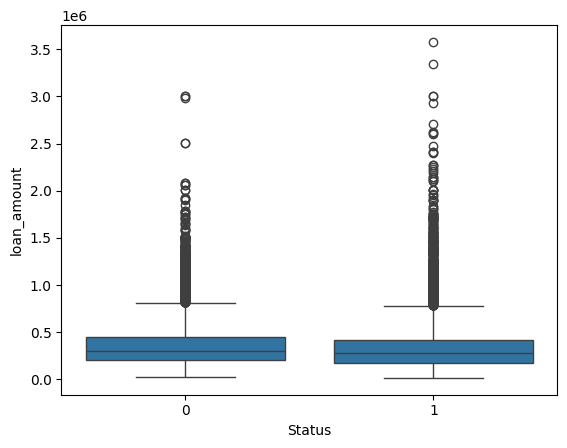

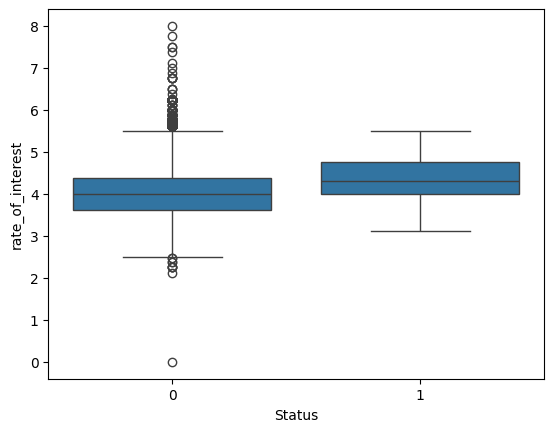

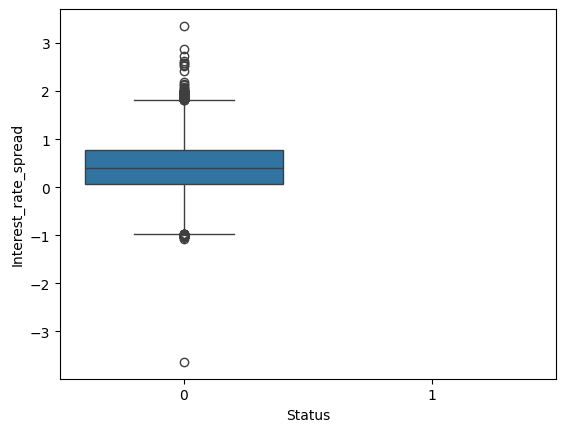

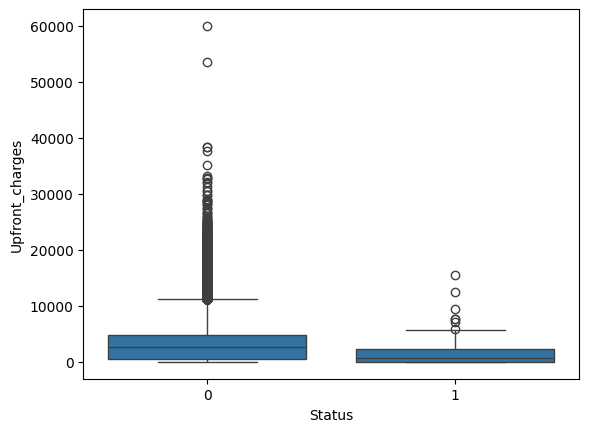

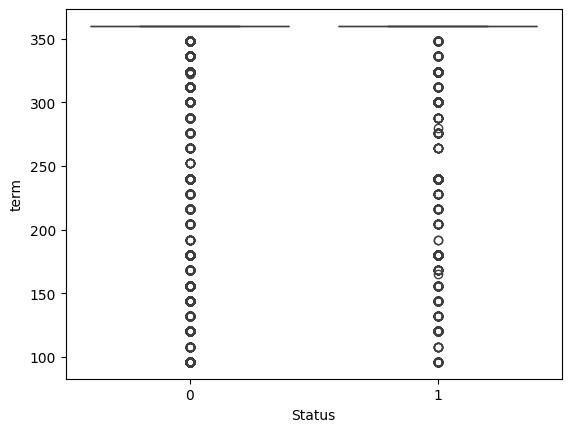

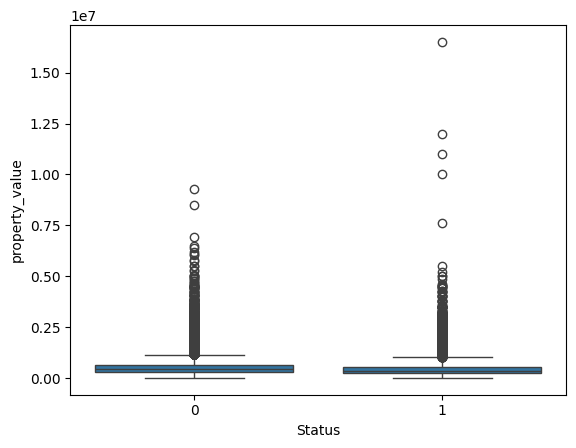

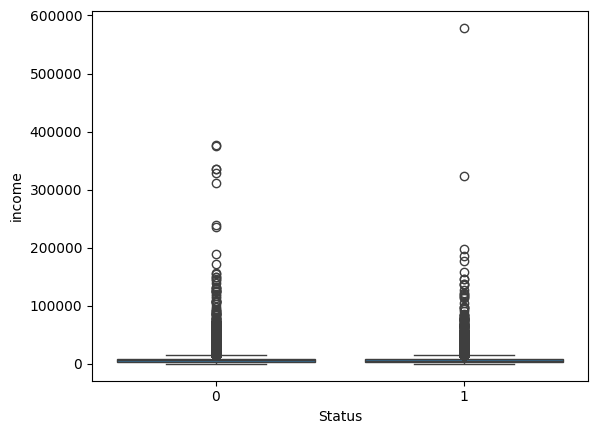

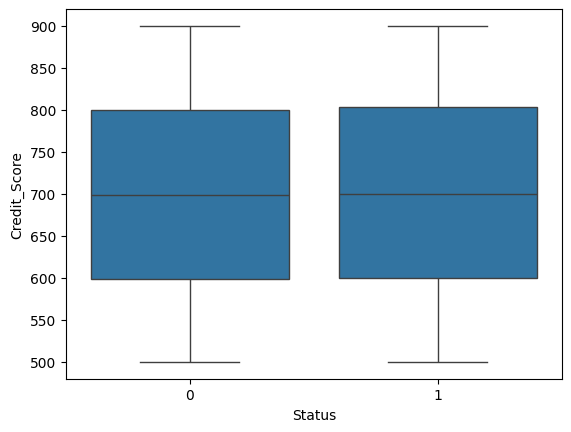

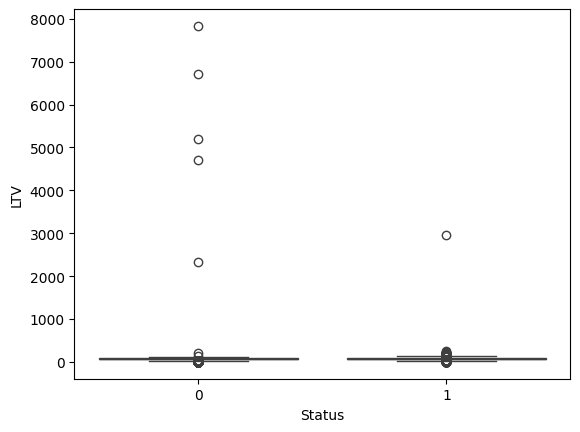

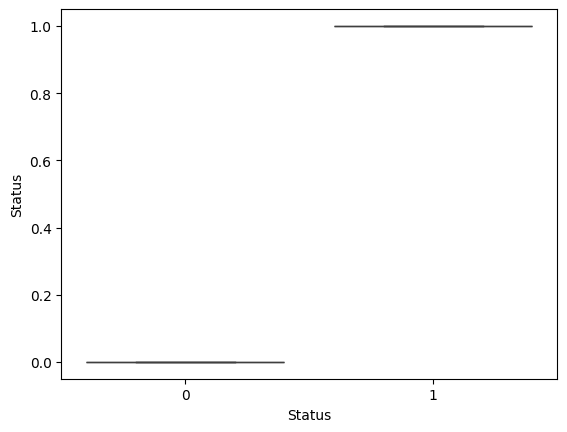

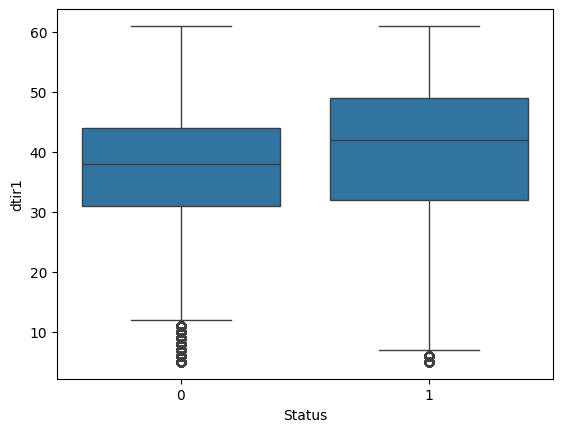

In [25]:
def box_target_plotter(data, target):
    for col in data.select_dtypes("number"):
        sns.boxplot(data=data, x=target, y=col)
        plt.show()
       
box_target_plotter(loan_df, "Status")

<Axes: xlabel='loan_amount', ylabel='Percent'>

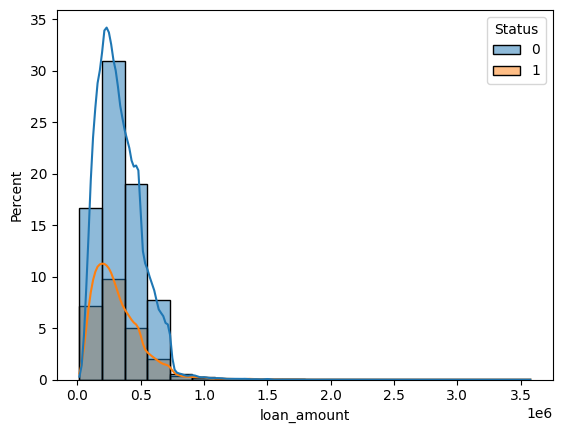

In [26]:
sns.histplot(loan_df, x="loan_amount", hue="Status", stat="percent", kde=True, bins=20)

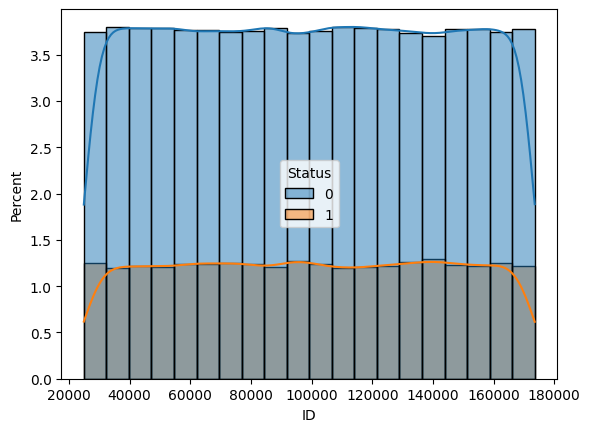

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

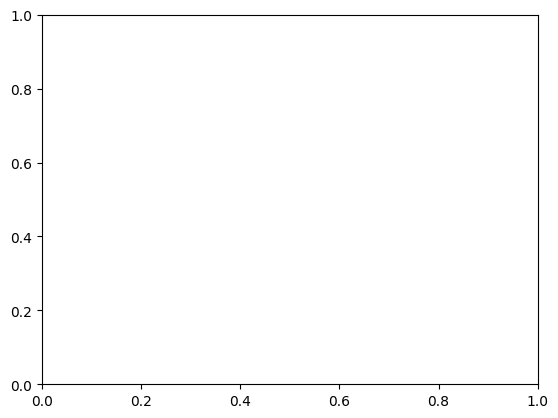

In [28]:
def hist_target_plotter(data, target):
    for col in data.select_dtypes("number"):
        sns.histplot(data=data, x=col, hue=target, stat="percent", kde=True, bins=20
                   )
        plt.show()
       
hist_target_plotter(loan_df, "Status")

C:\Users\Itanas\AppData\Local\Temp\ipykernel_36888\399886759.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(["object"]).columns:


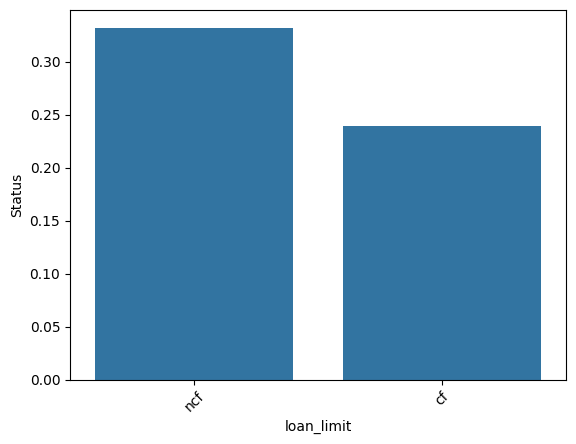

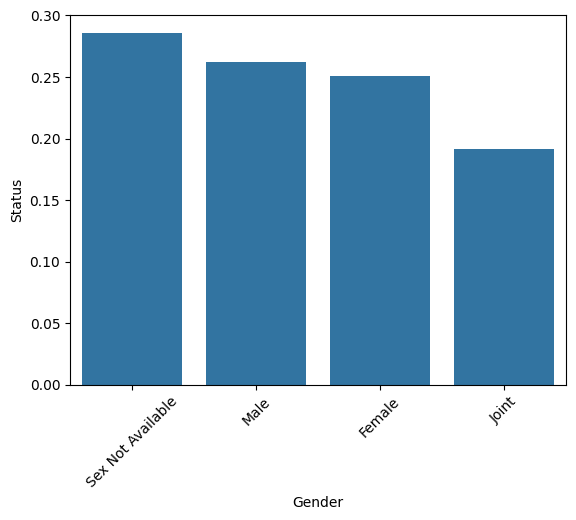

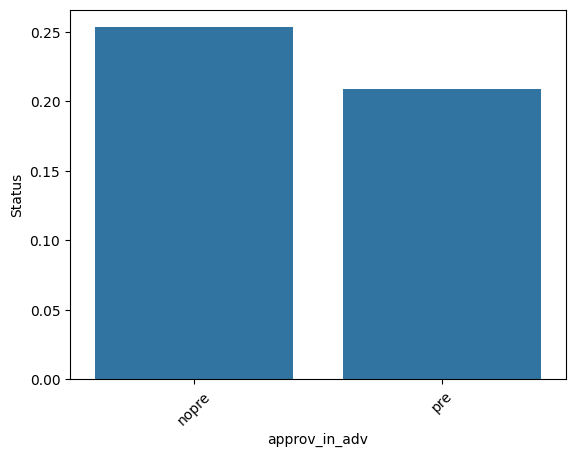

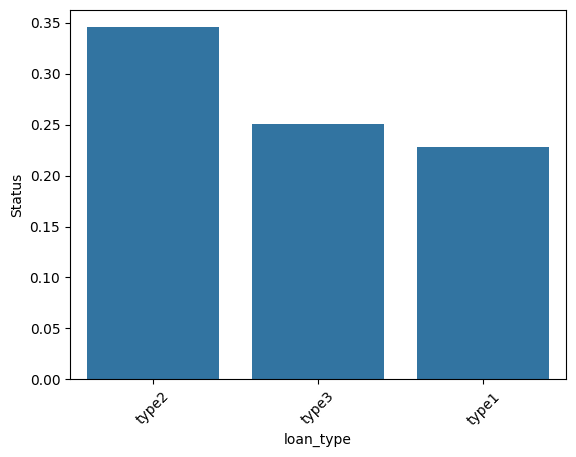

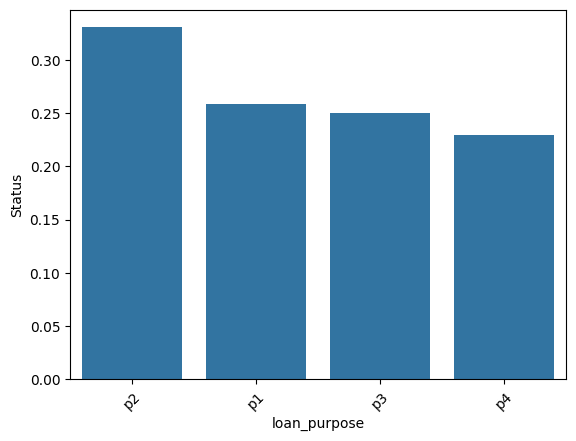

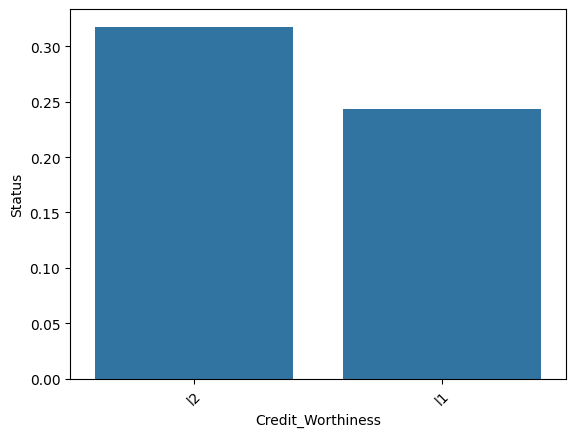

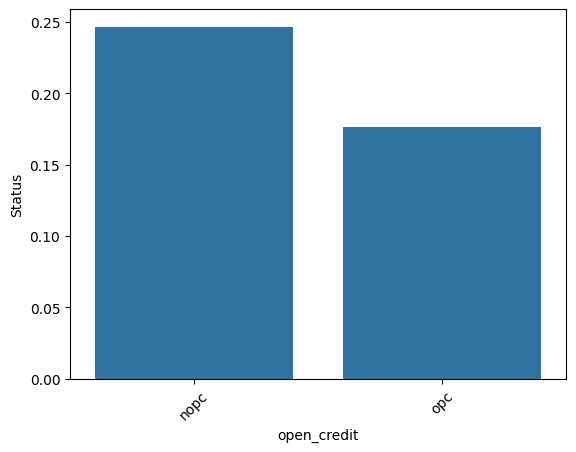

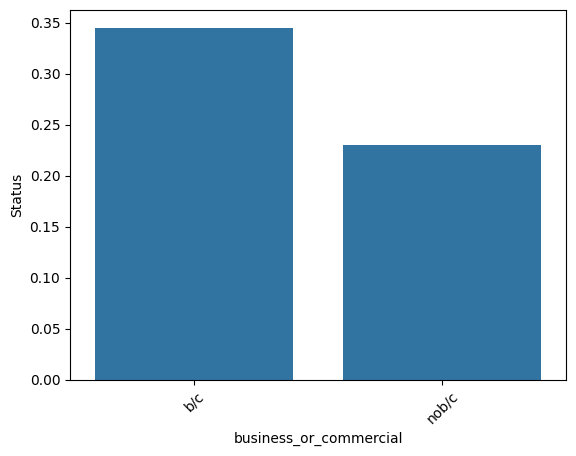

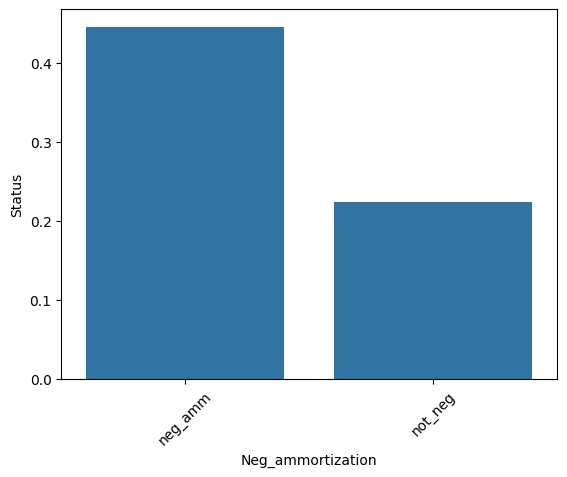

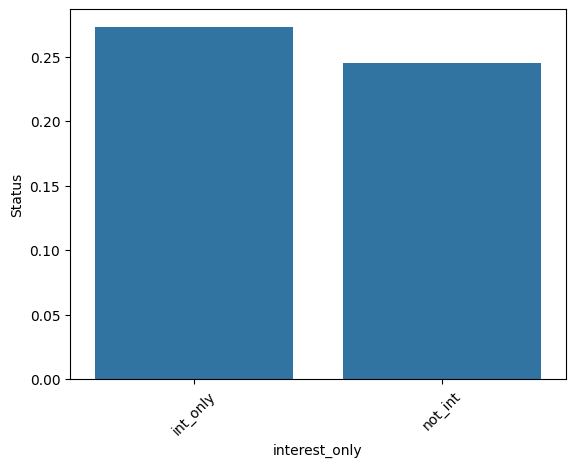

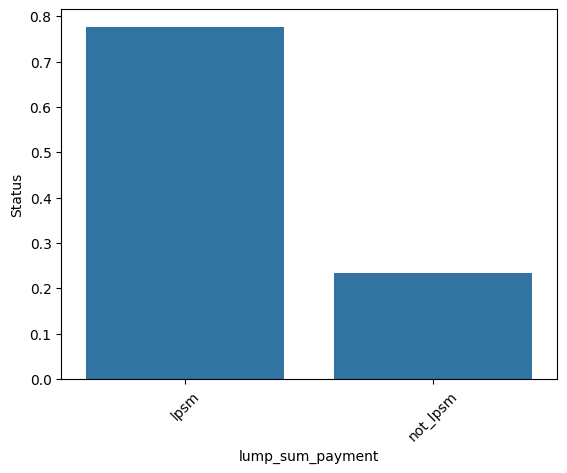

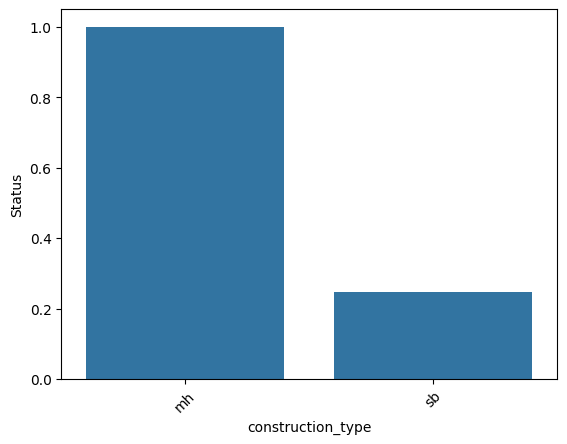

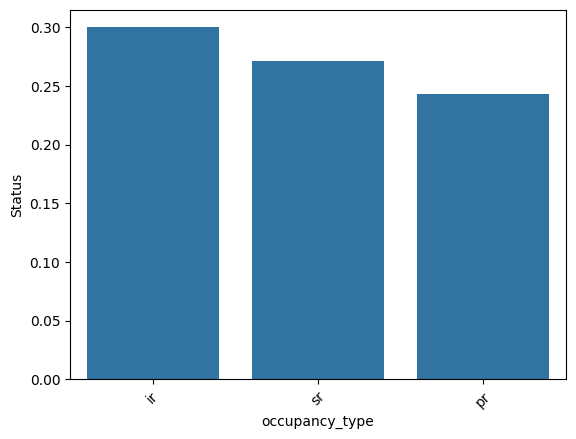

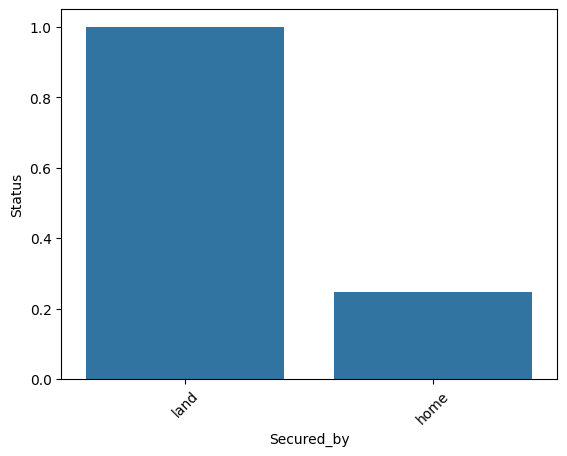

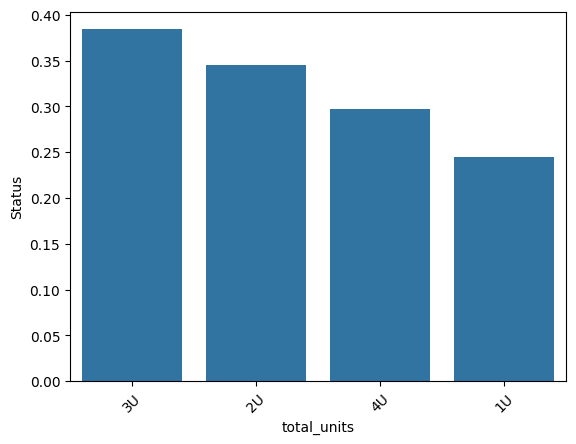

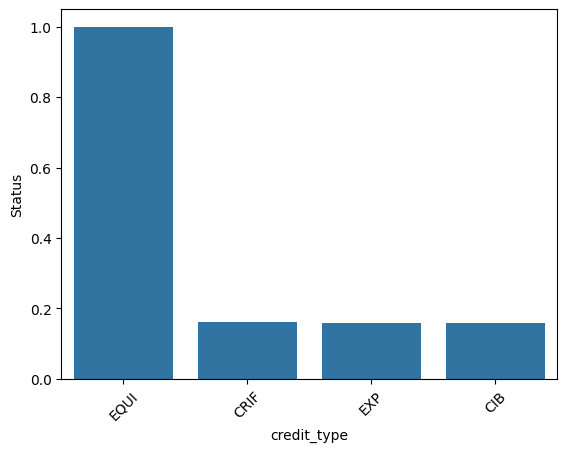

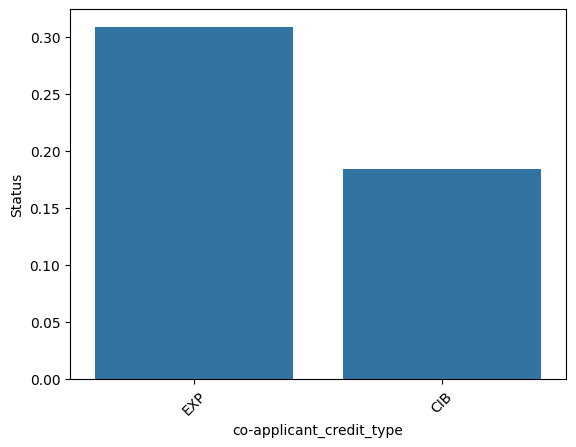

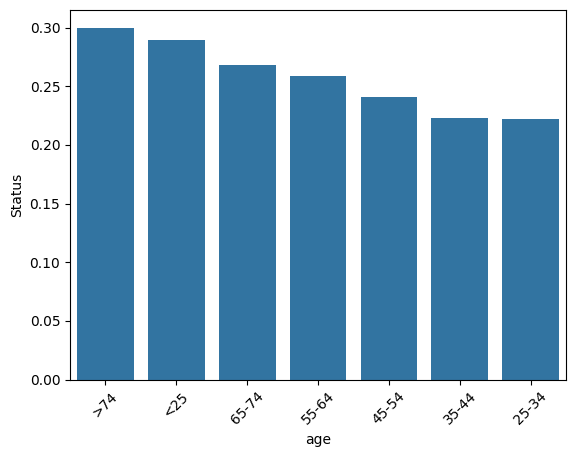

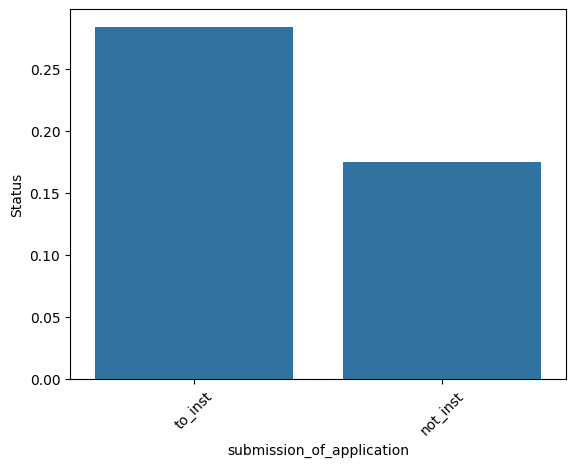

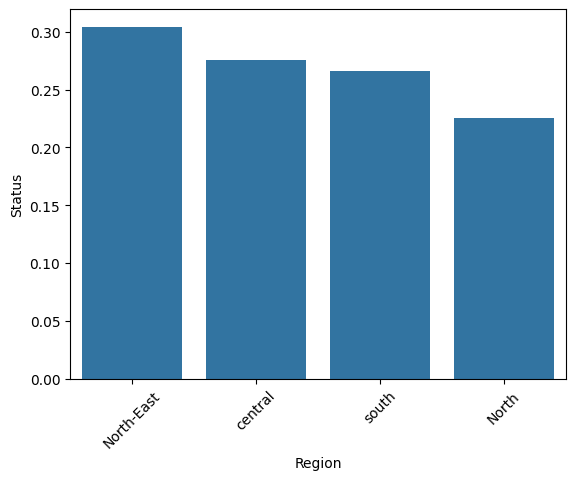

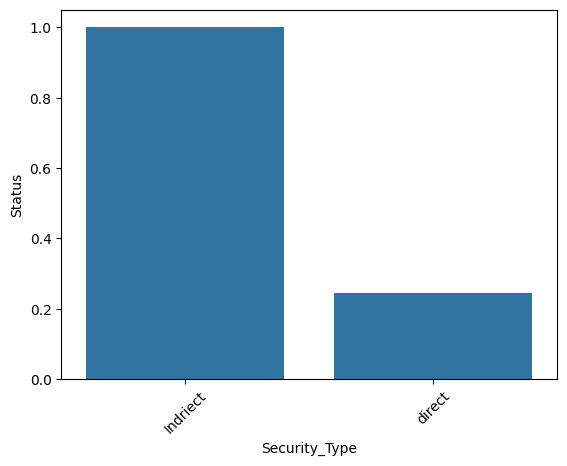

In [29]:
def cat_plotter(data, target):
    for col in data.select_dtypes(["object"]).columns:
        sns.barplot(
            data=(
                data
                .groupby(col, as_index=False)
                .agg({target: "mean"})
                .sort_values(by=target, ascending=False)
                 ),
            x=col,
            y=target)
        plt.xticks(rotation=45)
        plt.show()
       
cat_plotter(loan_df, "Status")

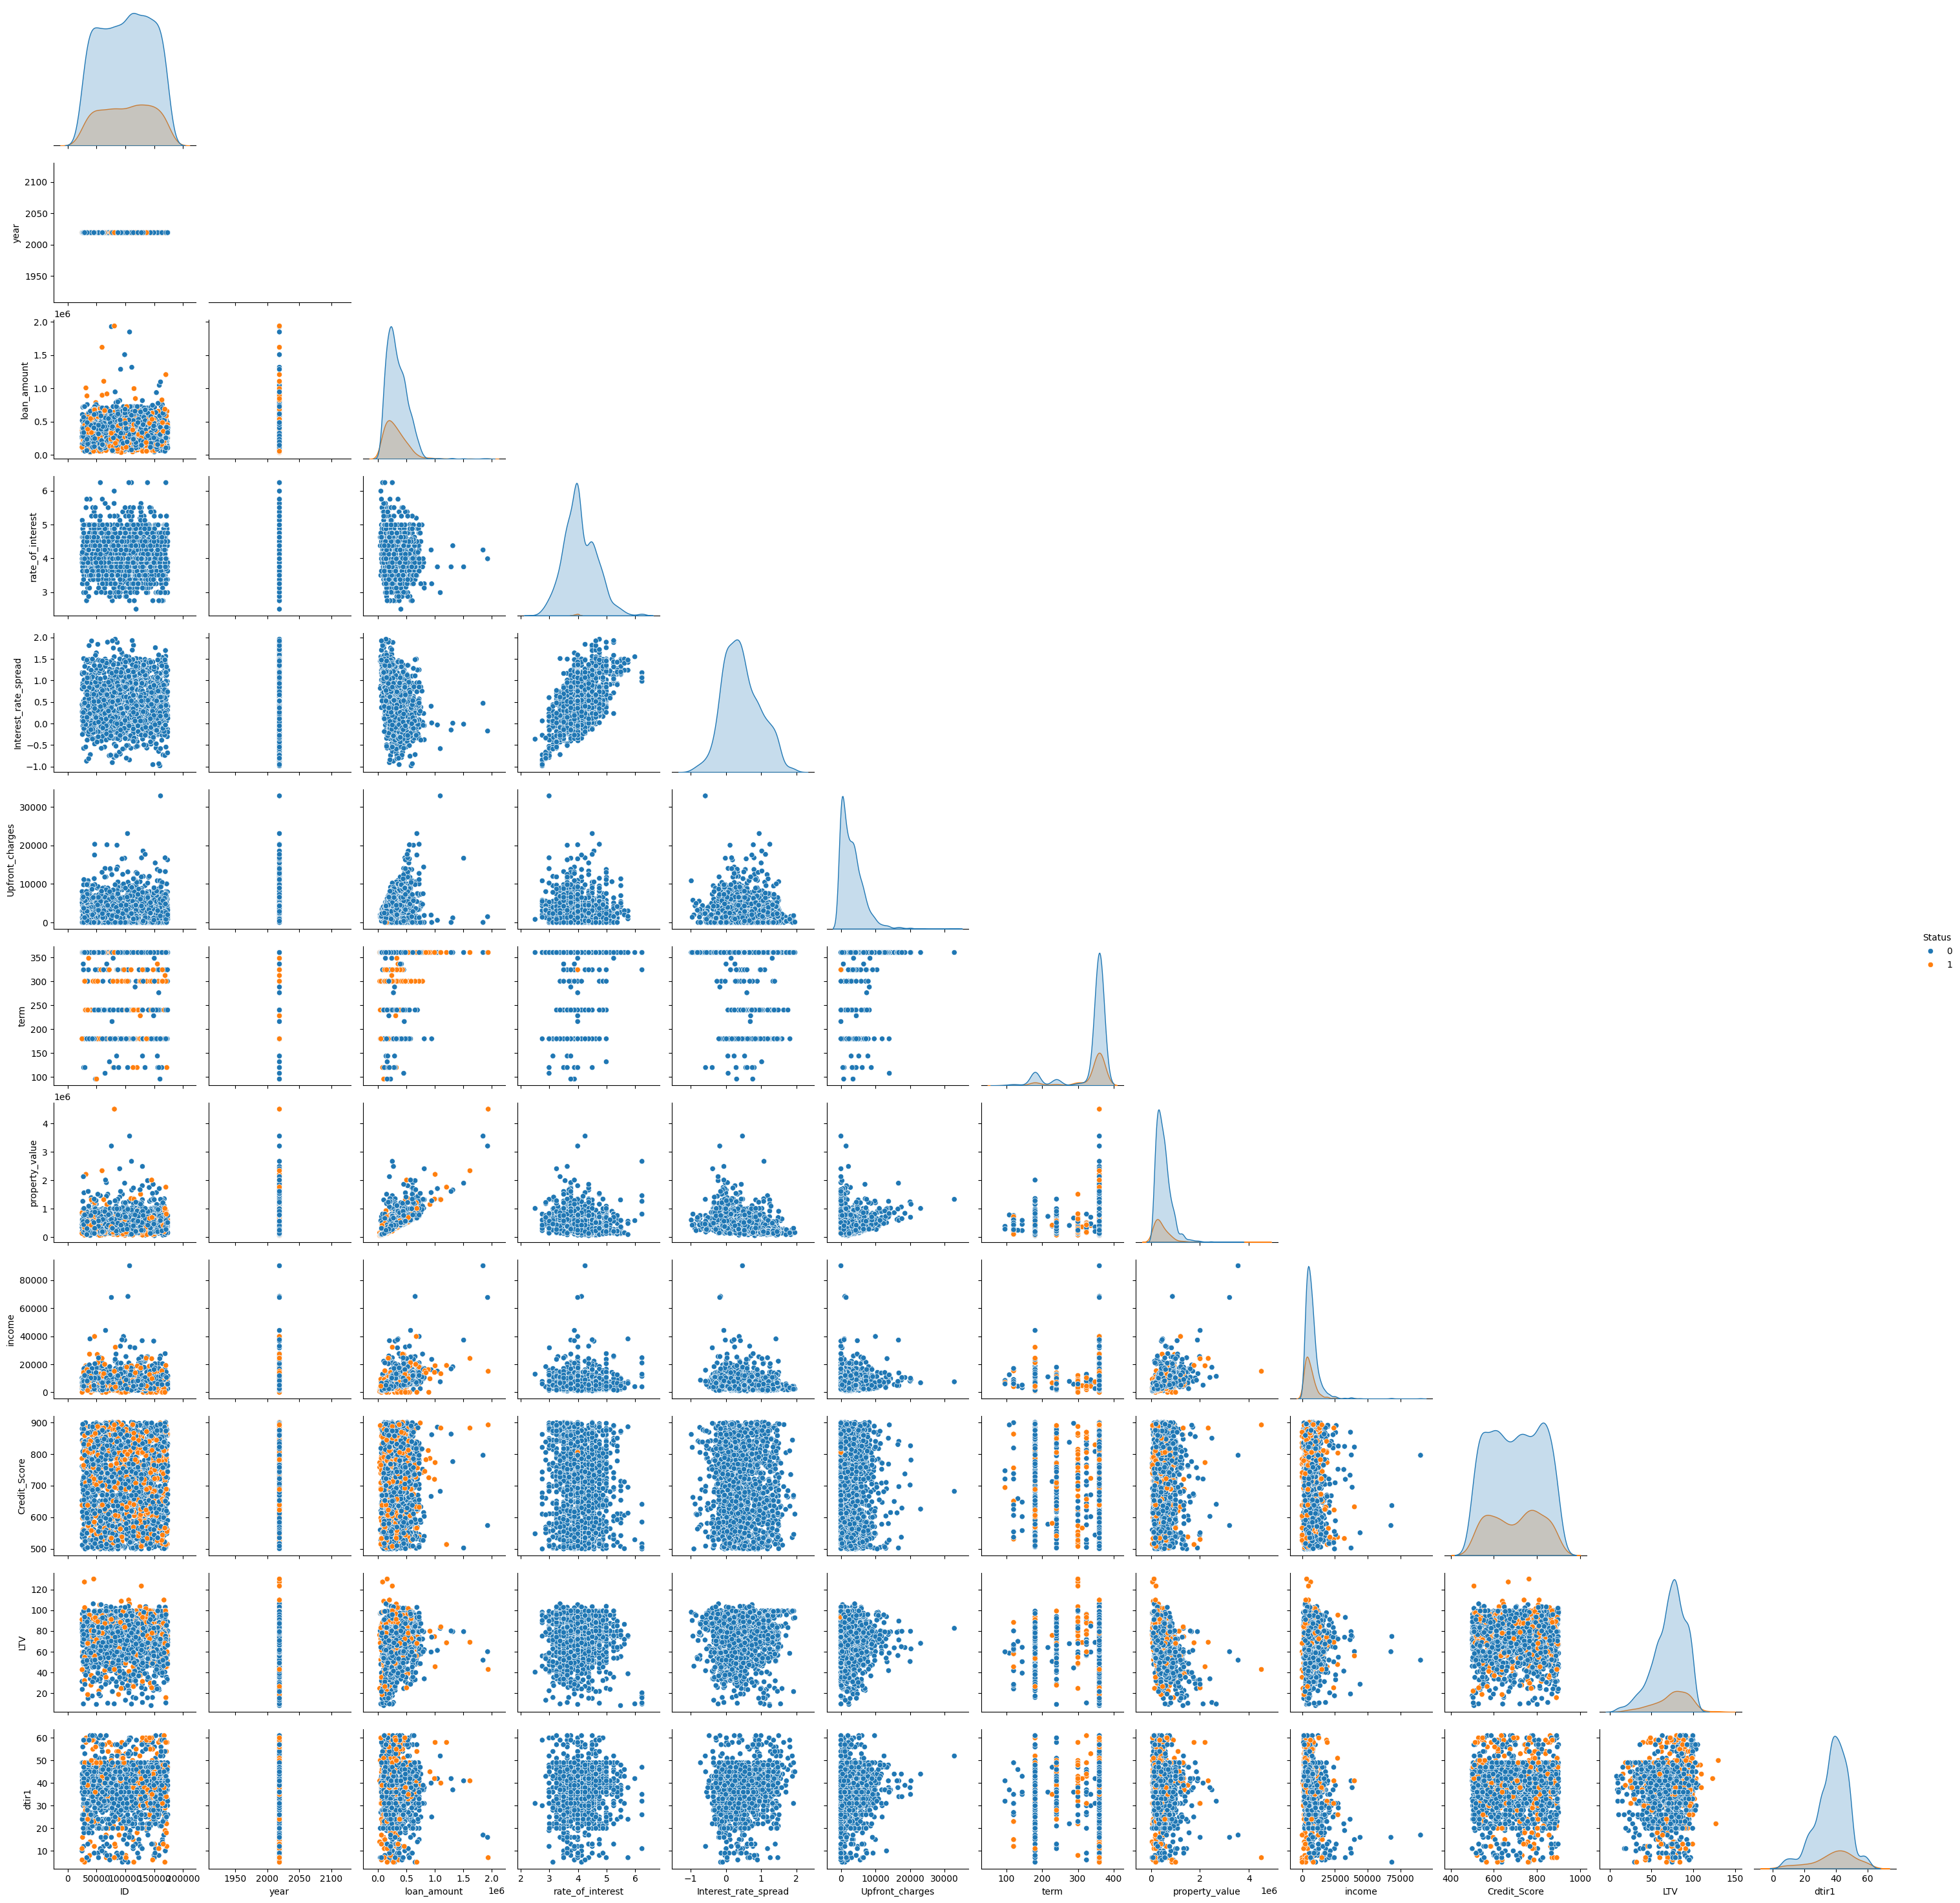

In [30]:
sns.pairplot(loan_df.sample(2000), hue="Status", corner=True)

<Axes: xlabel='loan_amount', ylabel='income'>

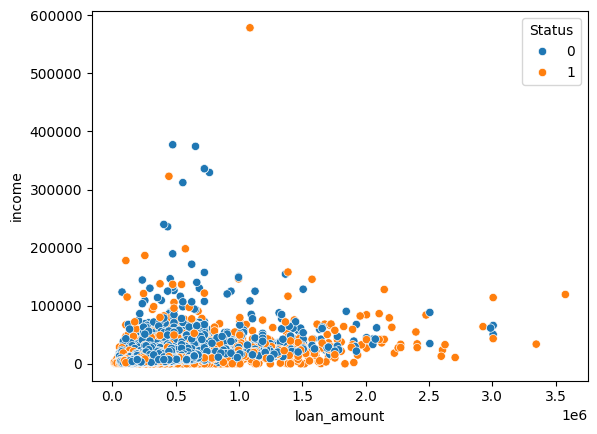

In [32]:
sns.scatterplot(loan_df, x="loan_amount", y="income", hue="Status" )

C:\Users\Itanas\AppData\Local\Temp\ipykernel_36888\3980741272.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in loan_df.select_dtypes("object").columns:


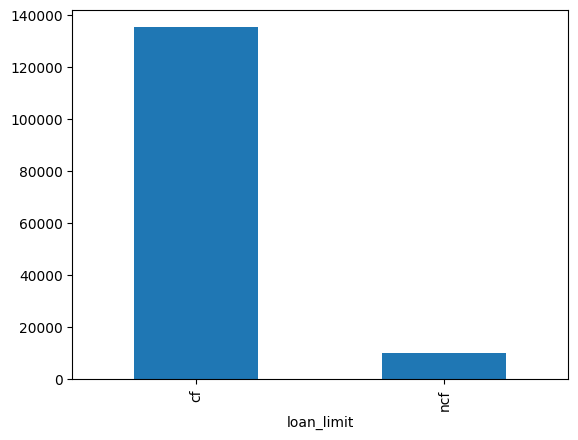

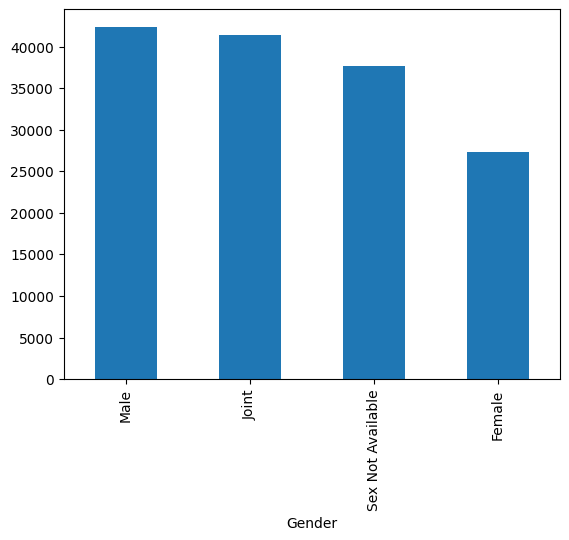

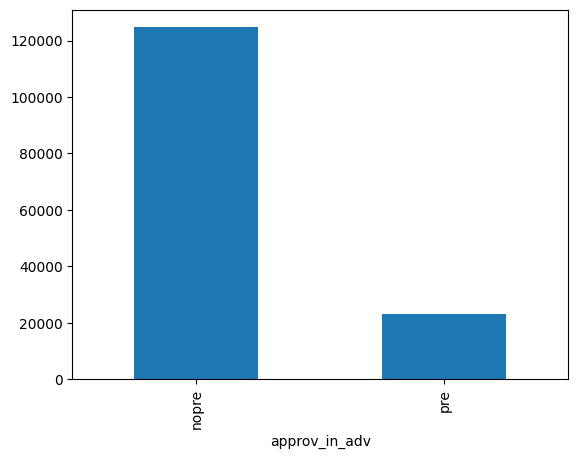

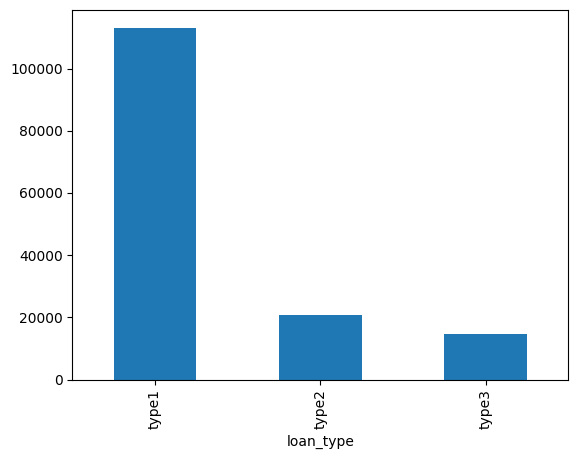

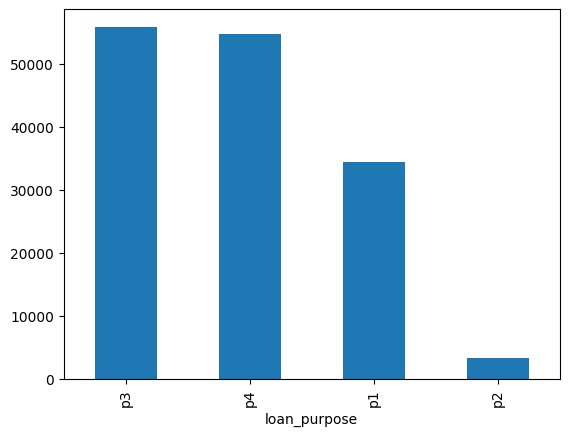

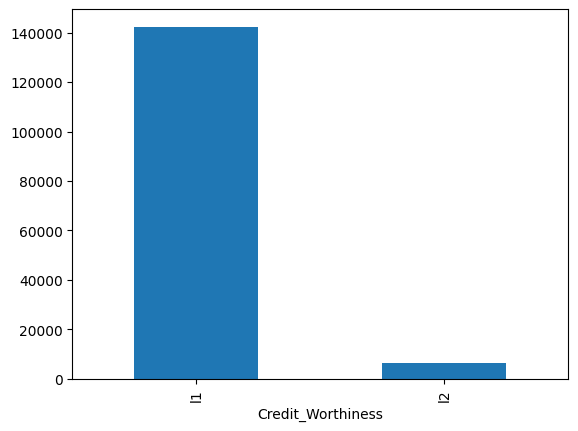

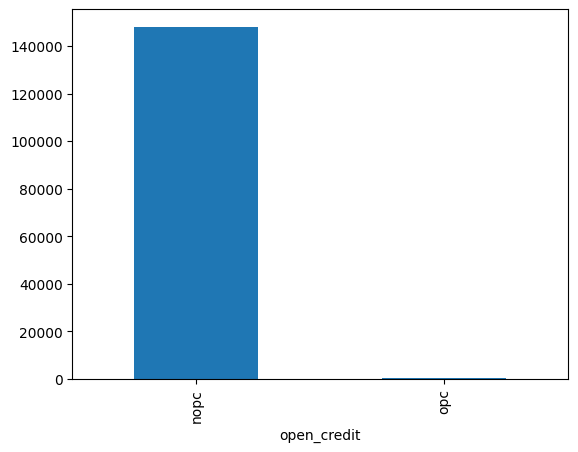

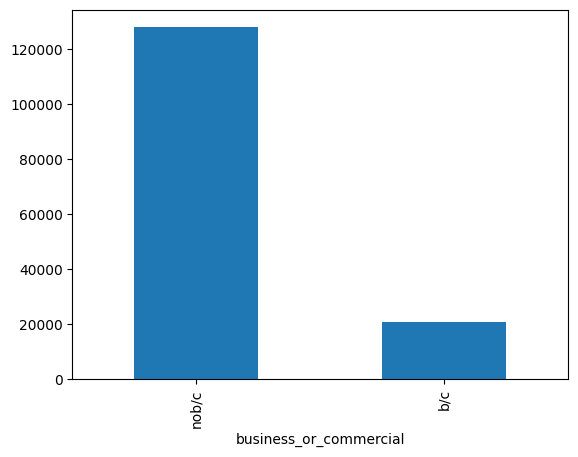

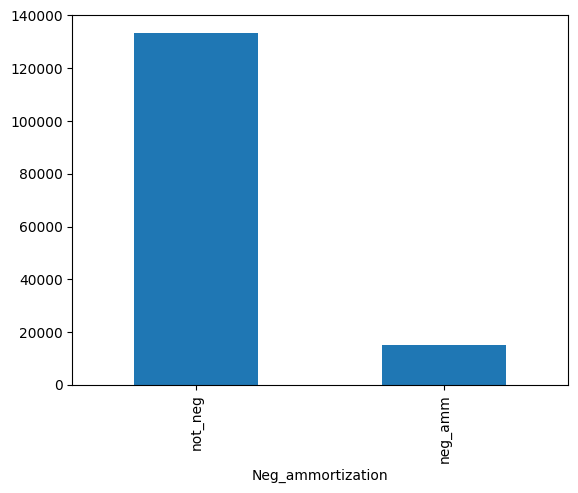

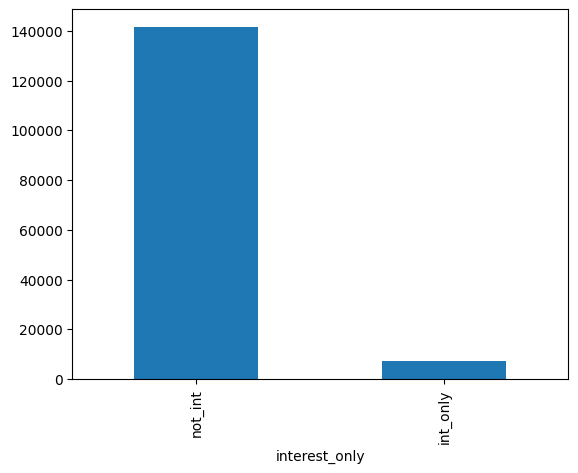

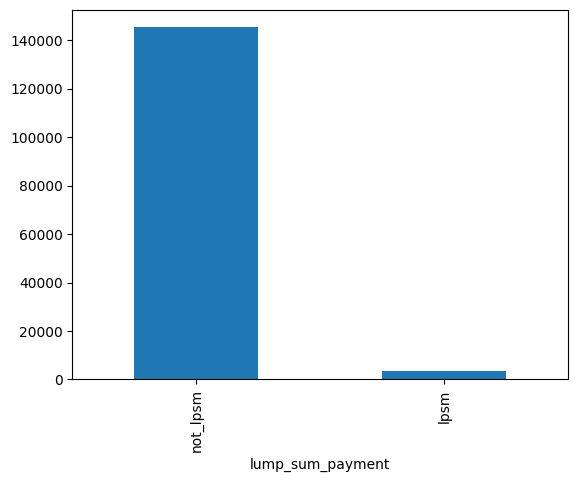

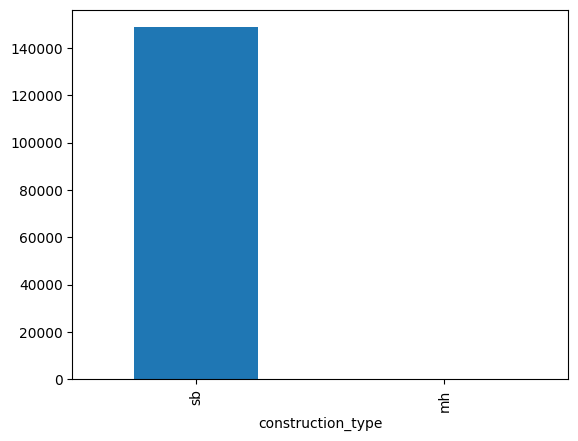

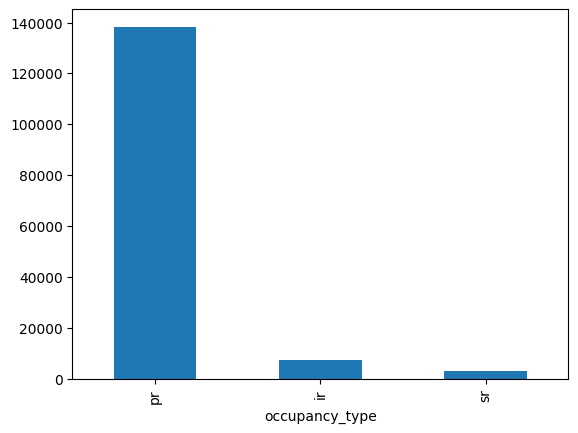

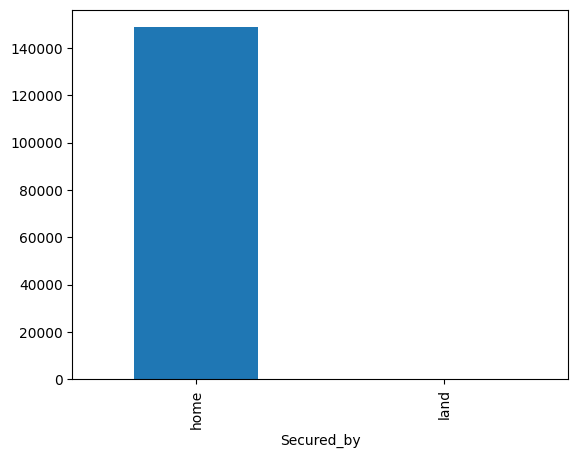

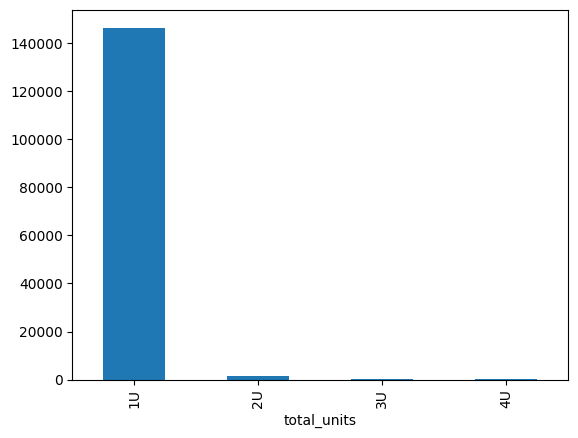

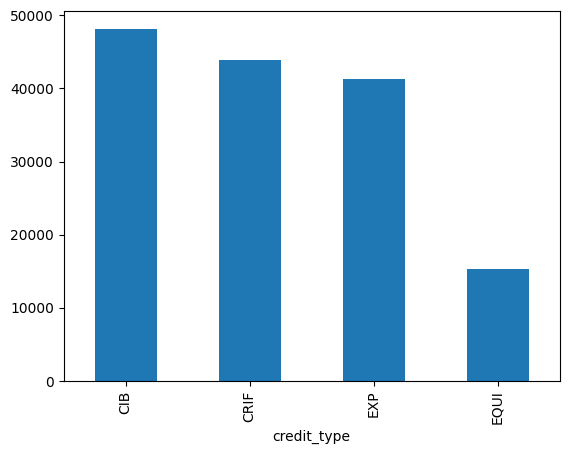

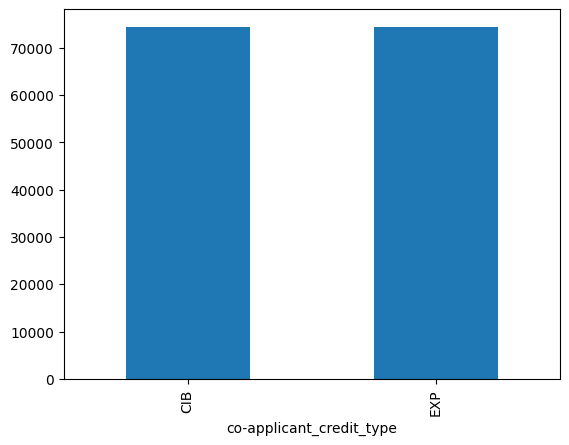

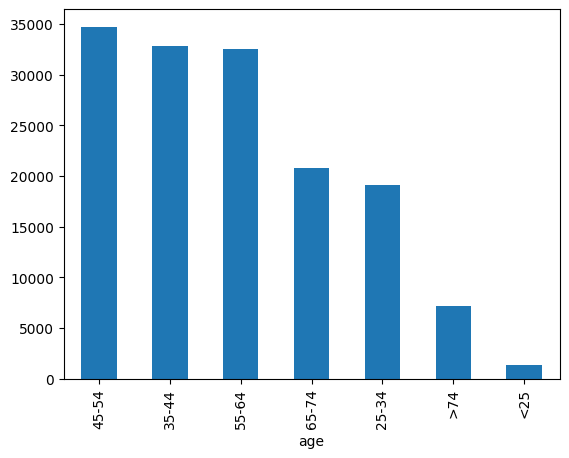

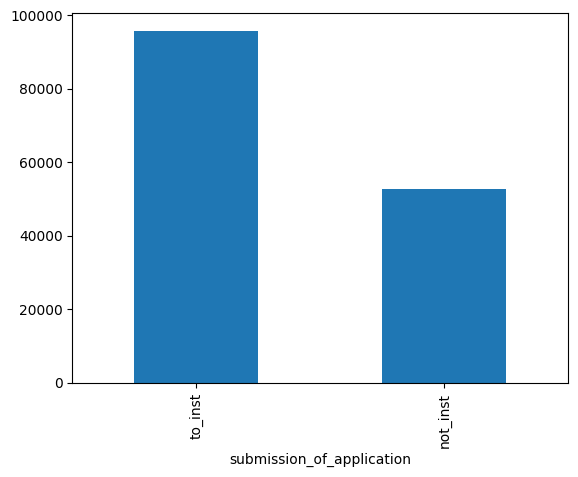

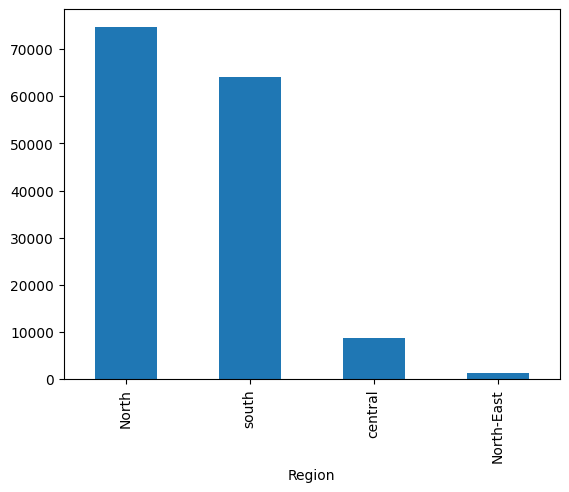

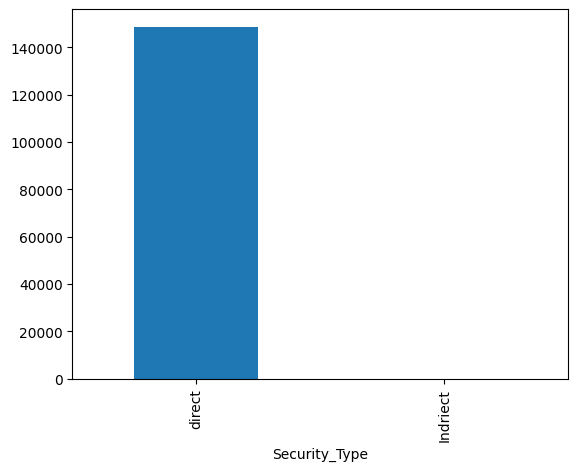

In [33]:
for column in loan_df.select_dtypes("object").columns:
    loan_df[column].value_counts(normalize=False).plot.bar()
    plt.show()

In [34]:
(loan_df[["Credit_Score", "loan_amount"]]
 - loan_df[["Credit_Score", "loan_amount"]].mean()) / loan_df[["Credit_Score", "loan_amount"]].std()

,Credit_Score,loan_amount
0,0.502356,-1.166976
1,-1.275409,-0.677604
2,1.158230,0.409888
3,-0.973362,0.681761
4,-0.843913,1.986752
...,...,...
148665,-0.352007,0.573012
148666,-1.128700,1.388631
148667,0.019080,0.627387
148668,0.321127,-0.731979


In [35]:
from sklearn.preprocessing import StandardScaler
 
std = StandardScaler()
 
std.fit_transform(loan_df[["Credit_Score", "loan_amount"]])

array([[ 0.50235739, -1.16697989],
       [-1.27541323, -0.6776066 ],
       [ 1.15823392,  0.40988958],
       ...,
       [ 0.01907994,  0.62738881],
       [ 0.32112834, -0.73198141],
       [ 1.12371411,  0.40988958]], shape=(148670, 2))

In [36]:
loan_df["total_units"].value_counts()

total_units
1U    146480
2U      1477
3U       393
4U       320
Name: count, dtype: int64

In [37]:
loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
)
 
loan_df[["total_units", "loan_amt_v_income"]].head()

,total_units,loan_amt_v_income
0,1U,66.954023
1,1U,41.465863
2,1U,42.879747
3,1U,38.425926
4,1U,66.714559


<Axes: xlabel='loan_amt_v_income', ylabel='Count'>

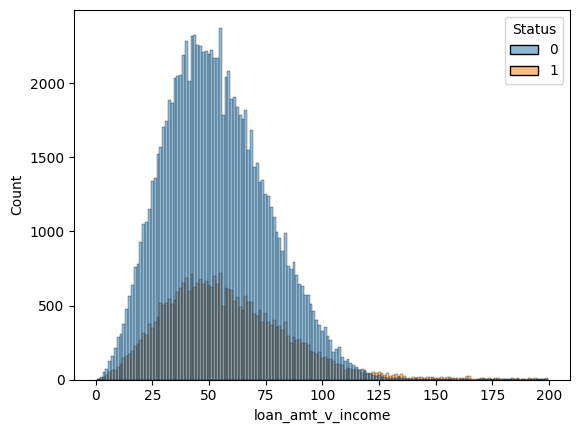

In [38]:
sns.histplot(
    loan_df.query("loan_amt_v_income < 200"),
    hue="Status",
    x="loan_amt_v_income"
)

In [40]:
def add_deviation_feature(X, feature, category):
   
    # temp groupby object
    category_gb = X.groupby(category)[feature]
   
    # create columns of category means and standard deviations
    category_mean = category_gb.transform(lambda x: x.mean())
    category_std = category_gb.transform(lambda x: x.std())
   
    # compute stds from category mean for each feature value,
    # add to X as new feature
    deviation_feature = (X[feature] - category_mean) / category_std
    X[feature + '_Dev_' + category] = deviation_feature
 
 
add_deviation_feature(loan_df, 'income', 'Region')
 
loan_df[["income", "Region", "income_Dev_Region"]].sample(20).sort_values("income")

,income,Region,income_Dev_Region
63973,2580.0,North,-0.657679
22648,3480.0,south,-0.544083
86299,3660.0,south,-0.516297
59006,4800.0,south,-0.340318
64867,5580.0,south,-0.219911
74172,5820.0,south,-0.182863
38881,6300.0,south,-0.108766
99895,6480.0,south,-0.080980
70819,6600.0,south,-0.062456
98531,6840.0,south,-0.025408


In [41]:
# Drop useless/unpromising columns
 
prep_loan_df = loan_df.drop([
    "year",
     "ID",
     "open_credit",
    "construction_type",
    "Security_Type",
    "Secured_by"],
    axis=1
)
 
prep_loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  str    
 1   Gender                     148670 non-null  str    
 2   approv_in_adv              147762 non-null  str    
 3   loan_type                  148670 non-null  str    
 4   loan_purpose               148536 non-null  str    
 5   Credit_Worthiness          148670 non-null  str    
 6   business_or_commercial     148670 non-null  str    
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           112231 non-null  float64
 9   Interest_rate_spread       112031 non-null  float64
 10  Upfront_charges            109028 non-null  float64
 11  term                       148629 non-null  float64
 12  Neg_ammortization          148549 non-null  str    
 13  interest_only              148670 non-nu

In [42]:
# data splitting
 
from sklearn.model_selection import train_test_split
 
X = pd.get_dummies(prep_loan_df[["loan_limit", "Gender", "loan_amount"]], drop_first=True)
y = prep_loan_df["Status"]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=2023)
 
print(f"Training Size: {X_train.shape[0]}, Test Size: {X_test.shape[0]}")

Training Size: 118936, Test Size: 29734


In [43]:
# feature scaling
 
from sklearn.preprocessing import StandardScaler
 
std = StandardScaler()
 
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)